In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

# Machine Learning - Regression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             mean_absolute_percentage_error)

# Statistical Analysis
from scipy import stats
from scipy.stats import pearsonr

print("✅ All libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")
print(f"📊 Dataset: 100,000 Insurance Records | 54+ Features")

✅ All libraries imported successfully!
📦 Pandas version: 2.2.2
📦 NumPy version: 2.0.2
📊 Dataset: 100,000 Insurance Records | 54+ Features


In [3]:
url = 'https://drive.google.com/uc?export=download&id=1SOMpQNhr5CPDdj5flrMUdwMEQVYeehaa'
df = pd.read_csv(url)
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00


In [6]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


=== SHAPE ===
(100000, 54)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker            

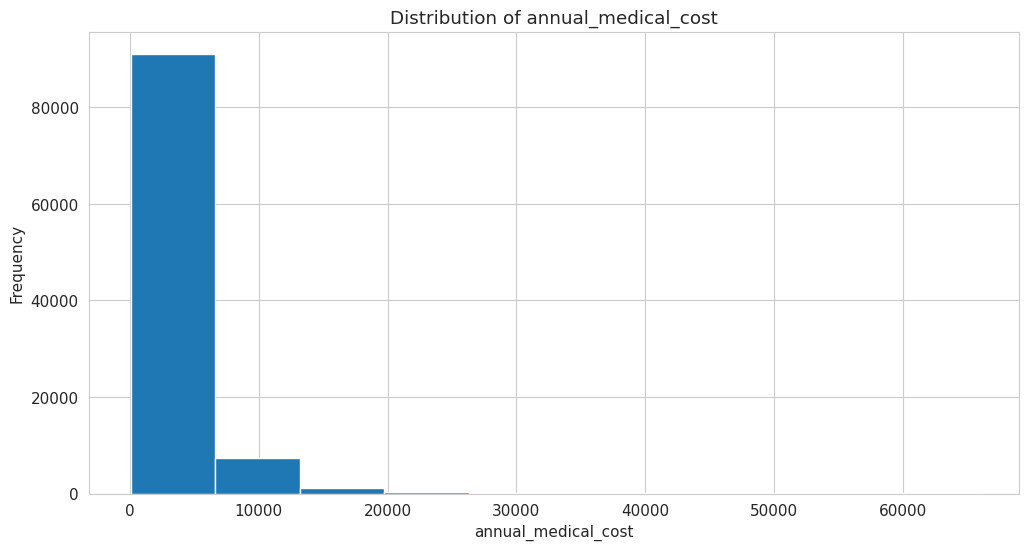

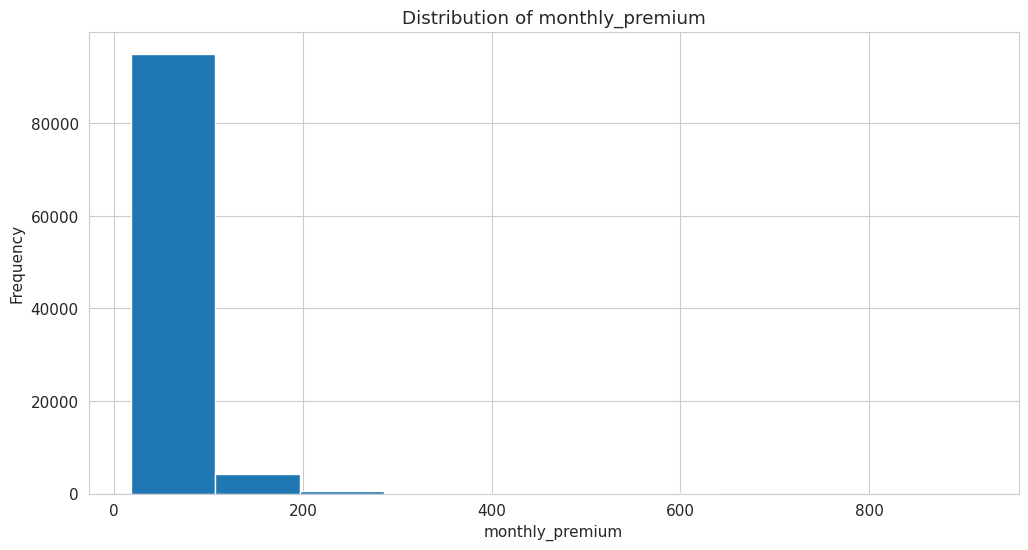

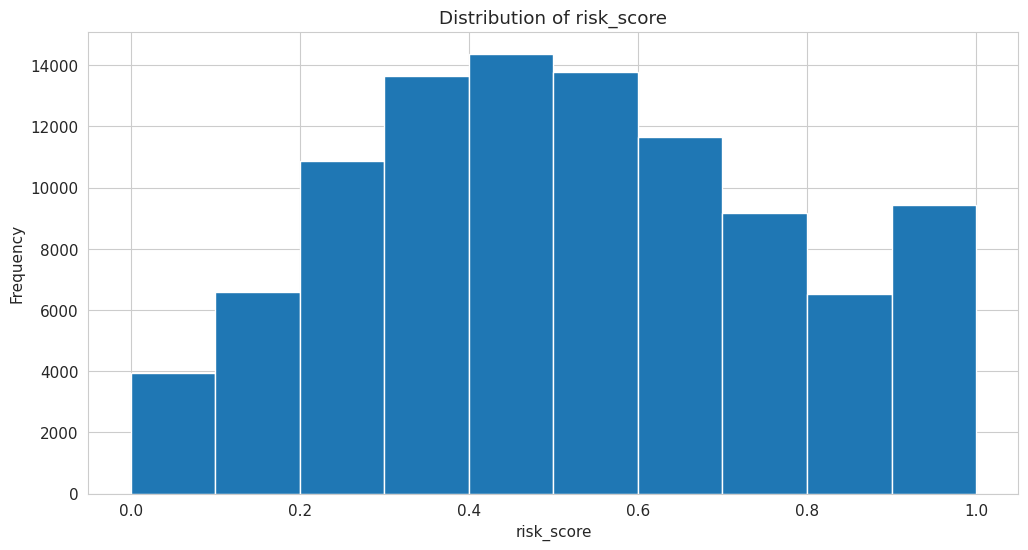

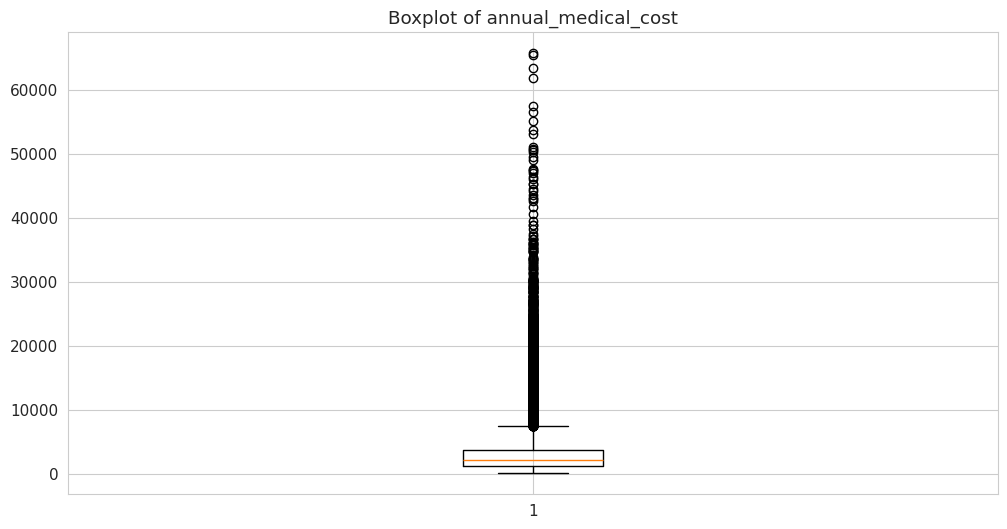

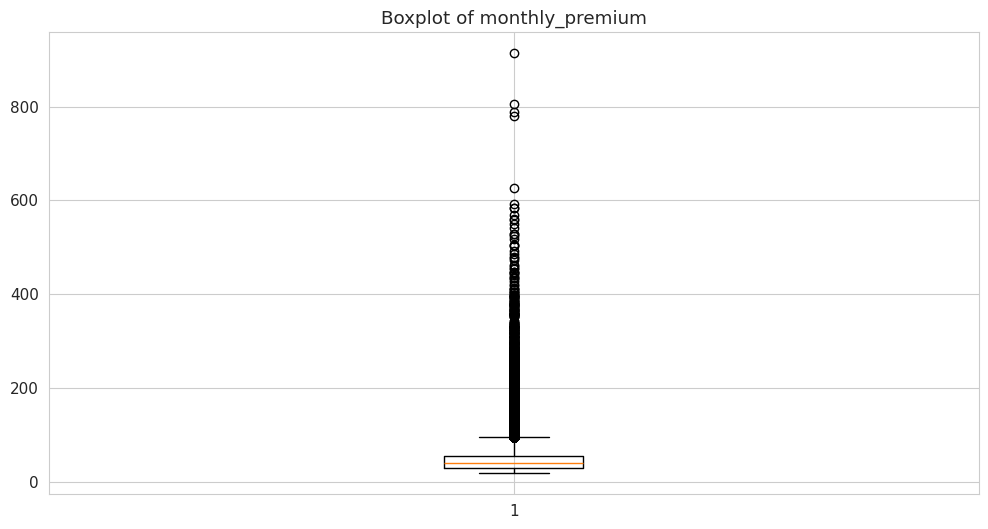

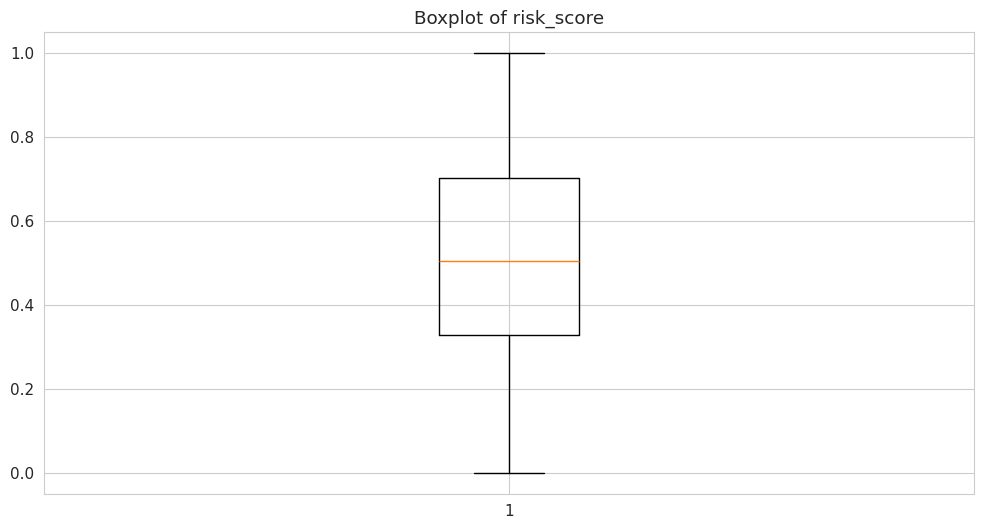


=== VALUE COUNTS: sex ===
sex
Female    49193
Male      48794
Other      2013
Name: count, dtype: int64

=== VALUE COUNTS: region ===
region
South      28029
North      22027
East       19984
West       17879
Central    12081
Name: count, dtype: int64

=== VALUE COUNTS: urban_rural ===
urban_rural
Urban       60019
Suburban    25021
Rural       14960
Name: count, dtype: int64

=== VALUE COUNTS: education ===
education
Bachelors       27996
Some College    25112
HS              24827
Masters         13987
No HS            5120
Doctorate        2958
Name: count, dtype: int64

=== VALUE COUNTS: marital_status ===
marital_status
Married     53252
Single      35715
Divorced     6984
Widowed      4049
Name: count, dtype: int64

=== VALUE COUNTS: employment_status ===
employment_status
Employed         55269
Retired          19864
Unemployed       12939
Self-employed    11928
Name: count, dtype: int64

=== VALUE COUNTS: smoker ===
smoker
Never      69709
Former     18163
Current    12128
Nam

In [7]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== INFO ===")
print(df.info())

print("\n=== HEAD ===")
print(df.head())

# ==============================
# 4. STATISTICAL SUMMARY
# ==============================
print("\n=== DESCRIBE ===")
print(df.describe(include='all'))

# ==============================
# 5. MISSING VALUES
# ==============================
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

print(missing_df)

# ==============================
# 6. DUPLICATE CHECK
# ==============================
print("\n=== DUPLICATES ===")
print(df.duplicated().sum())

# ==============================
# 7. DATA TYPES CHECK
# ==============================
print("\n=== DATA TYPES ===")
print(df.dtypes)

# ==============================
# 8. CORRELATION MATRIX
# ==============================
corr = df.corr(numeric_only=True)

print("\n=== CORRELATION ===")
print(corr["annual_medical_cost"].sort_values(ascending=False))

# ==============================
# 9. DISTRIBUTION PLOTS
# ==============================
numeric_cols = [
    "annual_medical_cost",
    "monthly_premium",
    "risk_score"
]

for col in numeric_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# ==============================
# 10. OUTLIER CHECK (BOXPLOT)
# ==============================
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# ==============================
# 11. CATEGORICAL ANALYSIS
# ==============================
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n=== VALUE COUNTS: {col} ===")
    print(df[col].value_counts())

# ==============================
# 12. GROUP ANALYSIS (IMPORTANT)
# ==============================
# Example: high risk vs low risk
if "is_high_risk" in df.columns:
    print("\n=== COST BY RISK GROUP ===")
    print(df.groupby("is_high_risk")["annual_medical_cost"].mean())

# Example: chronic condition impact
if "chronic_count" in df.columns:
    print("\n=== COST BY CHRONIC COUNT ===")
    print(df.groupby("chronic_count")["annual_medical_cost"].mean())


EDA sesuai dengan demografi pasien

In [8]:
demo_cols = [
    "age", "sex", "region", "urban_rural", "income",
    "education", "marital_status", "employment_status"
]

# mean cost
for col in demo_cols:
    print(f"\n{col}")
    print(df.groupby(col)["annual_medical_cost"].mean().sort_values(ascending=False))


age
age
89    5551.002353
97    4825.204444
94    4739.640000
96    4386.447407
93    4384.416596
         ...     
11    2104.297706
3     2068.360000
6     1945.366813
2     1647.704595
1     1306.842041
Name: annual_medical_cost, Length: 101, dtype: float64

sex
sex
Male      3019.940991
Female    3000.034652
Other     2985.337978
Name: annual_medical_cost, dtype: float64

region
region
South      3044.083503
West       3022.908888
North      3002.007163
East       2981.961138
Central    2968.236324
Name: annual_medical_cost, dtype: float64

urban_rural
urban_rural
Suburban    3023.081440
Urban       3005.683082
Rural       3001.776546
Name: annual_medical_cost, dtype: float64

income
income
272300.0    26867.91
256500.0    21763.69
529300.0    21114.89
279600.0    18824.85
394900.0    18542.43
              ...   
263100.0      296.53
216300.0      241.53
230500.0      224.48
449800.0      224.38
163000.0      186.85
Name: annual_medical_cost, Length: 2987, dtype: float64

educati

EDA Sesuai lifestle

In [9]:
life_cols = ["bmi", "smoker", "alcohol_freq"]

for col in life_cols:
    print(f"\n{col}")
    print(df.groupby(col)["annual_medical_cost"].mean())


bmi
bmi
12.0    2701.850139
12.1    2018.015455
12.2    1295.592857
12.3    3049.997500
12.4    1528.694545
           ...     
46.7    6687.520000
47.3    4653.480000
47.8    6858.000000
50.1    1454.580000
50.4    3124.110000
Name: annual_medical_cost, Length: 340, dtype: float64

smoker
smoker
Current    4295.561051
Former     3161.766632
Never      2746.007817
Name: annual_medical_cost, dtype: float64

alcohol_freq
alcohol_freq
Daily         3056.392715
Occasional    3008.221003
Weekly        2990.257019
Name: annual_medical_cost, dtype: float64


In [10]:
df.duplicated().sum()

np.int64(0)

Eda sesuai dengan kondisi pasien

In [11]:
health_cols = [
    "hypertension","diabetes","copd","cardiovascular_disease",
    "cancer_history","kidney_disease","liver_disease",
    "arthritis","mental_health"
]

for col in health_cols:
    print(f"\n{col}")
    print(df.groupby(col)["annual_medical_cost"].mean())


hypertension
hypertension
0    2765.556574
1    3964.353982
Name: annual_medical_cost, dtype: float64

diabetes
diabetes
0    2906.492493
1    4104.670247
Name: annual_medical_cost, dtype: float64

copd
copd
0    2967.271997
1    4140.565739
Name: annual_medical_cost, dtype: float64

cardiovascular_disease
cardiovascular_disease
0    2952.428070
1    4066.827848
Name: annual_medical_cost, dtype: float64

cancer_history
cancer_history
0    2983.861747
1    4173.548419
Name: annual_medical_cost, dtype: float64

kidney_disease
kidney_disease
0    2993.528690
1    4082.668003
Name: annual_medical_cost, dtype: float64

liver_disease
liver_disease
0    2990.014304
1    4306.033460
Name: annual_medical_cost, dtype: float64

arthritis
arthritis
0    2883.695569
1    4044.773379
Name: annual_medical_cost, dtype: float64

mental_health
mental_health
0    2856.751875
1    4030.103899
Name: annual_medical_cost, dtype: float64


EDA sesai dengan lama di di RS

In [12]:
util_cols = [
    "visits_last_year",
    "hospitalizations_last_3yrs",
    "days_hospitalized_last_3yrs",
    "medication_count"
]

for col in util_cols:
    print(f"\n{col}")
    print(df[[col, "annual_medical_cost"]].corr())


visits_last_year
                     visits_last_year  annual_medical_cost
visits_last_year             1.000000             0.195631
annual_medical_cost          0.195631             1.000000

hospitalizations_last_3yrs
                            hospitalizations_last_3yrs  annual_medical_cost
hospitalizations_last_3yrs                     1.00000              0.20864
annual_medical_cost                            0.20864              1.00000

days_hospitalized_last_3yrs
                             days_hospitalized_last_3yrs  annual_medical_cost
days_hospitalized_last_3yrs                     1.000000             0.230246
annual_medical_cost                             0.230246             1.000000

medication_count
                     medication_count  annual_medical_cost
medication_count             1.000000             0.113456
annual_medical_cost          0.113456             1.000000


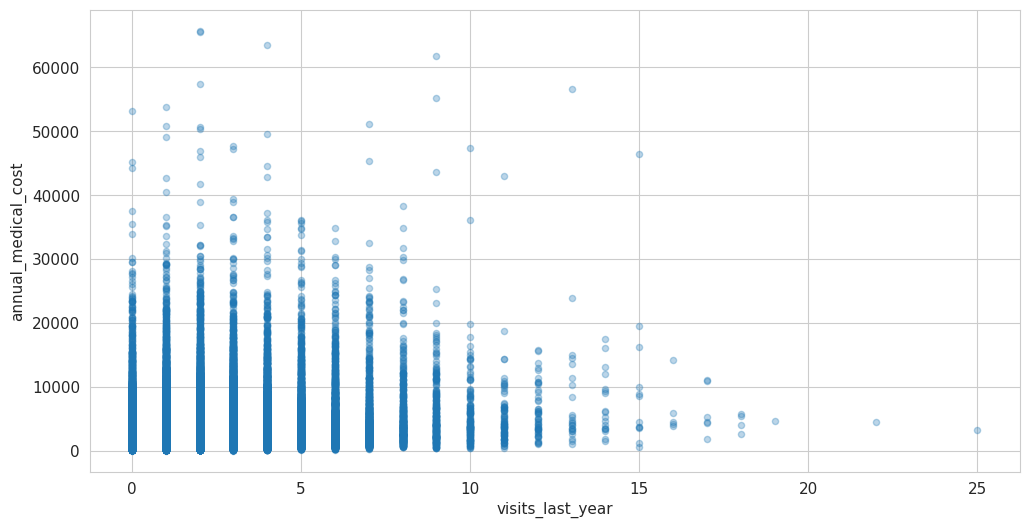

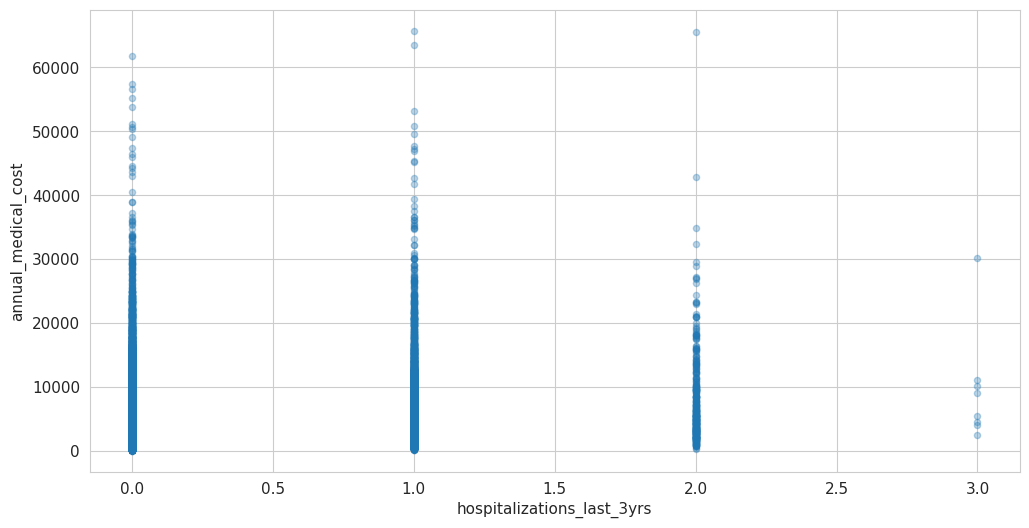

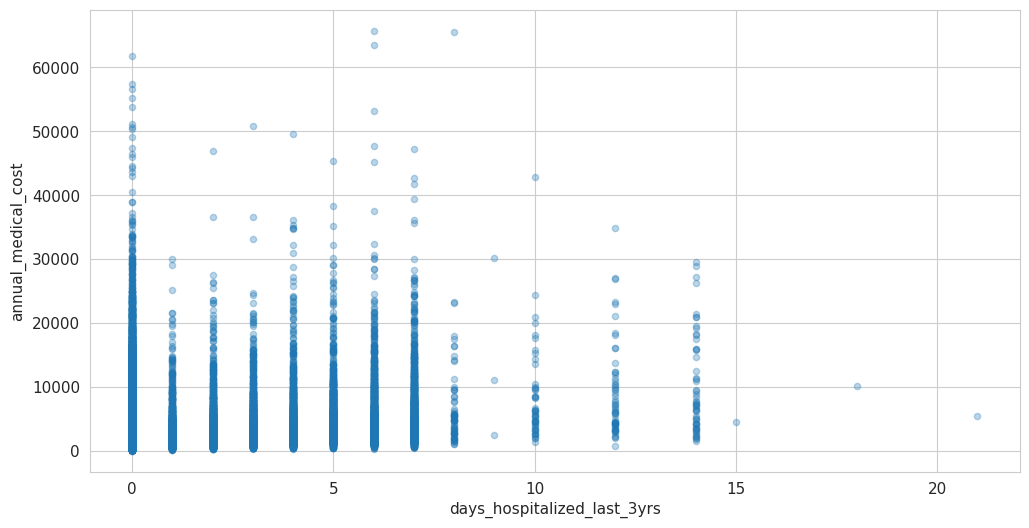

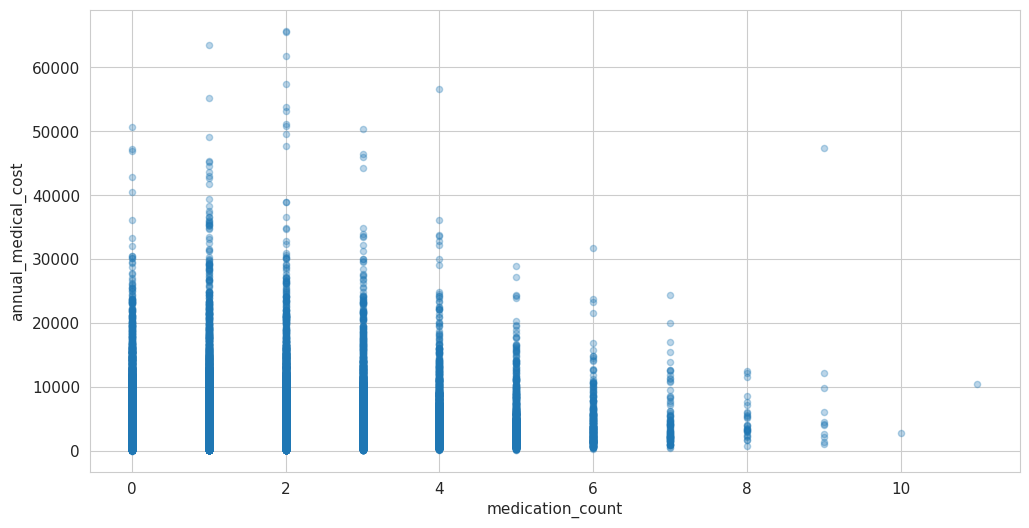

In [13]:
for col in util_cols:
    df.plot.scatter(x=col, y="annual_medical_cost", alpha=0.3)

EDA Sesai dengan policy Pasien

In [14]:
policy_cols = [
    "plan_type","network_tier","deductible",
    "copay","policy_term_years"
]

for col in policy_cols:
    print(f"\n{col}")
    print(df.groupby(col)["annual_medical_cost"].mean())


plan_type
plan_type
EPO    2994.298085
HMO    3014.030615
POS    3005.430057
PPO    3013.161008
Name: annual_medical_cost, dtype: float64

network_tier
network_tier
Bronze      3009.396357
Gold        3004.405930
Platinum    2997.494021
Silver      3014.969325
Name: annual_medical_cost, dtype: float64

deductible
deductible
500     3015.225469
1000    3016.098505
2000    2990.256557
5000    2993.412890
Name: annual_medical_cost, dtype: float64

copay
copay
10    3005.605728
20    3004.597654
30    3013.774142
50    3055.852922
Name: annual_medical_cost, dtype: float64

policy_term_years
policy_term_years
1     2973.412908
2     3031.041458
3     2971.733276
4     3062.808456
5     2963.782168
6     3038.348254
7     3018.433291
8     2991.461222
9     3015.825322
10    3025.895923
Name: annual_medical_cost, dtype: float64


EDA sesuai dengan Claim pasien

In [15]:
claims_cols = [
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid"
]

for col in claims_cols:
    print(df[[col, "annual_medical_cost"]].corr())

                     claims_count  annual_medical_cost
claims_count             1.000000             0.179082
annual_medical_cost      0.179082             1.000000
                     avg_claim_amount  annual_medical_cost
avg_claim_amount             1.000000             0.632996
annual_medical_cost          0.632996             1.000000
                     total_claims_paid  annual_medical_cost
total_claims_paid             1.000000             0.739402
annual_medical_cost           0.739402             1.000000


In [16]:
# high cost
threshold = df["annual_medical_cost"].quantile(0.9)
df["high_cost"] = (df["annual_medical_cost"] >= threshold).astype(int)

In [17]:
disease_cols = [
    "hypertension","diabetes","copd","cardiovascular_disease",
    "cancer_history","kidney_disease","liver_disease",
    "arthritis","mental_health"
]

df["disease_count"] = df[disease_cols].sum(axis=1)

Outlier check

In [18]:
# target
threshold = df["annual_medical_cost"].quantile(0.9)
df["high_cost"] = (df["annual_medical_cost"] >= threshold).astype(int)

# disease
disease_cols = [
    "hypertension","diabetes","copd","cardiovascular_disease",
    "cancer_history","kidney_disease","liver_disease",
    "arthritis","mental_health"
]

df["disease_count"] = df[disease_cols].sum(axis=1)

# outlier
Q1 = df["annual_medical_cost"].quantile(0.25)
Q3 = df["annual_medical_cost"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

df["is_outlier"] = df["annual_medical_cost"] > upper

df["outlier_type"] = "normal"
df.loc[(df["is_outlier"]) & (df["disease_count"] >= 2), "outlier_type"] = "expected"
df.loc[(df["is_outlier"]) & (df["disease_count"] < 2), "outlier_type"] = "unexpected"

In [19]:
df.groupby("outlier_type")[[
    "age","income","household_size","dependents"
]].mean()

,age,income,household_size,dependents
outlier_type,,,,
expected,53.594667,50069.022222,2.451556,0.912000
normal,47.193998,49903.672716,2.430429,0.897928
unexpected,51.251659,49163.113667,2.430341,0.900929


In [20]:
df.groupby("outlier_type")[["bmi"]].mean()

# categorical
df.groupby(["outlier_type","smoker"]).size().unstack()

df.groupby(["outlier_type","alcohol_freq"]).size().unstack()

alcohol_freq,Daily,Occasional,Weekly
outlier_type,,,
expected,109,1022,430
normal,4663,41994,18534
unexpected,234,2062,869


In [21]:
df.groupby("outlier_type")[[
    "risk_score","chronic_count","disease_count",
    "systolic_bp","diastolic_bp","ldl","hba1c"
]].mean()

,risk_score,chronic_count,disease_count,systolic_bp,diastolic_bp,ldl,hba1c
outlier_type,,,,,,,
expected,0.867204,2.333333,2.242667,128.950222,79.095111,122.387156,6.092276
normal,0.506950,0.683099,0.627430,117.441016,73.428412,119.871710,5.594413
unexpected,0.612958,0.782397,0.673375,119.851393,74.508846,120.905705,5.602216


In [22]:
for col in disease_cols:
    print(f"\n{col}")
    print(df.groupby("outlier_type")[col].mean())


hypertension
outlier_type
expected      0.609333
normal        0.192646
unexpected    0.224237
Name: hypertension, dtype: float64

diabetes
outlier_type
expected      0.298222
normal        0.081027
unexpected    0.081380
Name: diabetes, dtype: float64

copd
outlier_type
expected      0.130222
normal        0.033938
unexpected    0.030517
Name: copd, dtype: float64

cardiovascular_disease
outlier_type
expected      0.188444
normal        0.048108
unexpected    0.045997
Name: cardiovascular_disease, dtype: float64

cancer_history
outlier_type
expected      0.084444
normal        0.019940
unexpected    0.022556
Name: cancer_history, dtype: float64

kidney_disease
outlier_type
expected      0.053333
normal        0.013505
unexpected    0.018355
Name: kidney_disease, dtype: float64

liver_disease
outlier_type
expected      0.064889
normal        0.013741
unexpected    0.011057
Name: liver_disease, dtype: float64

arthritis
outlier_type
expected      0.377778
normal        0.101901
unexpec

In [23]:
df.groupby("outlier_type")[[
    "visits_last_year",
    "hospitalizations_last_3yrs",
    "days_hospitalized_last_3yrs",
    "medication_count"
]].mean()

,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count
outlier_type,,,,
expected,3.936000,0.233333,1.044444,2.186222
normal,1.867465,0.081102,0.309800,1.211664
unexpected,2.169173,0.282618,1.349624,1.272004


In [24]:
df.groupby("outlier_type")[[
    "proc_imaging_count",
    "proc_surgery_count",
    "proc_physio_count",
    "proc_consult_count",
    "proc_lab_count"
]].mean()

,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count
outlier_type,,,,,
expected,0.773333,0.395111,0.758667,0.759111,0.755556
normal,0.501201,0.152508,0.502467,0.502789,0.501995
unexpected,0.527864,0.168510,0.505971,0.519903,0.533835


In [25]:
df.groupby("outlier_type")[[
    "deductible","copay","policy_term_years",
    "policy_changes_last_2yrs","provider_quality"
]].mean()

# categorical
df.groupby(["outlier_type","plan_type"]).size().unstack()
df.groupby(["outlier_type","network_tier"]).size().unstack()

network_tier,Bronze,Gold,Platinum,Silver
outlier_type,,,,
expected,645,433,236,936
normal,27922,18555,9326,37425
unexpected,1365,894,447,1816


In [26]:
df["alcohol_freq"] = df["alcohol_freq"].fillna("Unknown")

In [27]:
df["risk_x_disease"] = df["risk_score"] * df["chronic_count"]
df["risk_x_hospital"] = df["risk_score"] * df["days_hospitalized_last_3yrs"]

In [28]:
df["severity_score"] = (
    df["risk_score"] * 0.5 +
    df["chronic_count"] * 0.3 +
    df["days_hospitalized_last_3yrs"] * 0.2
)

In [29]:
important_cols = [
    "risk_score",
    "chronic_count",
    "disease_count",
    "severity_score",
    "risk_x_disease"
]

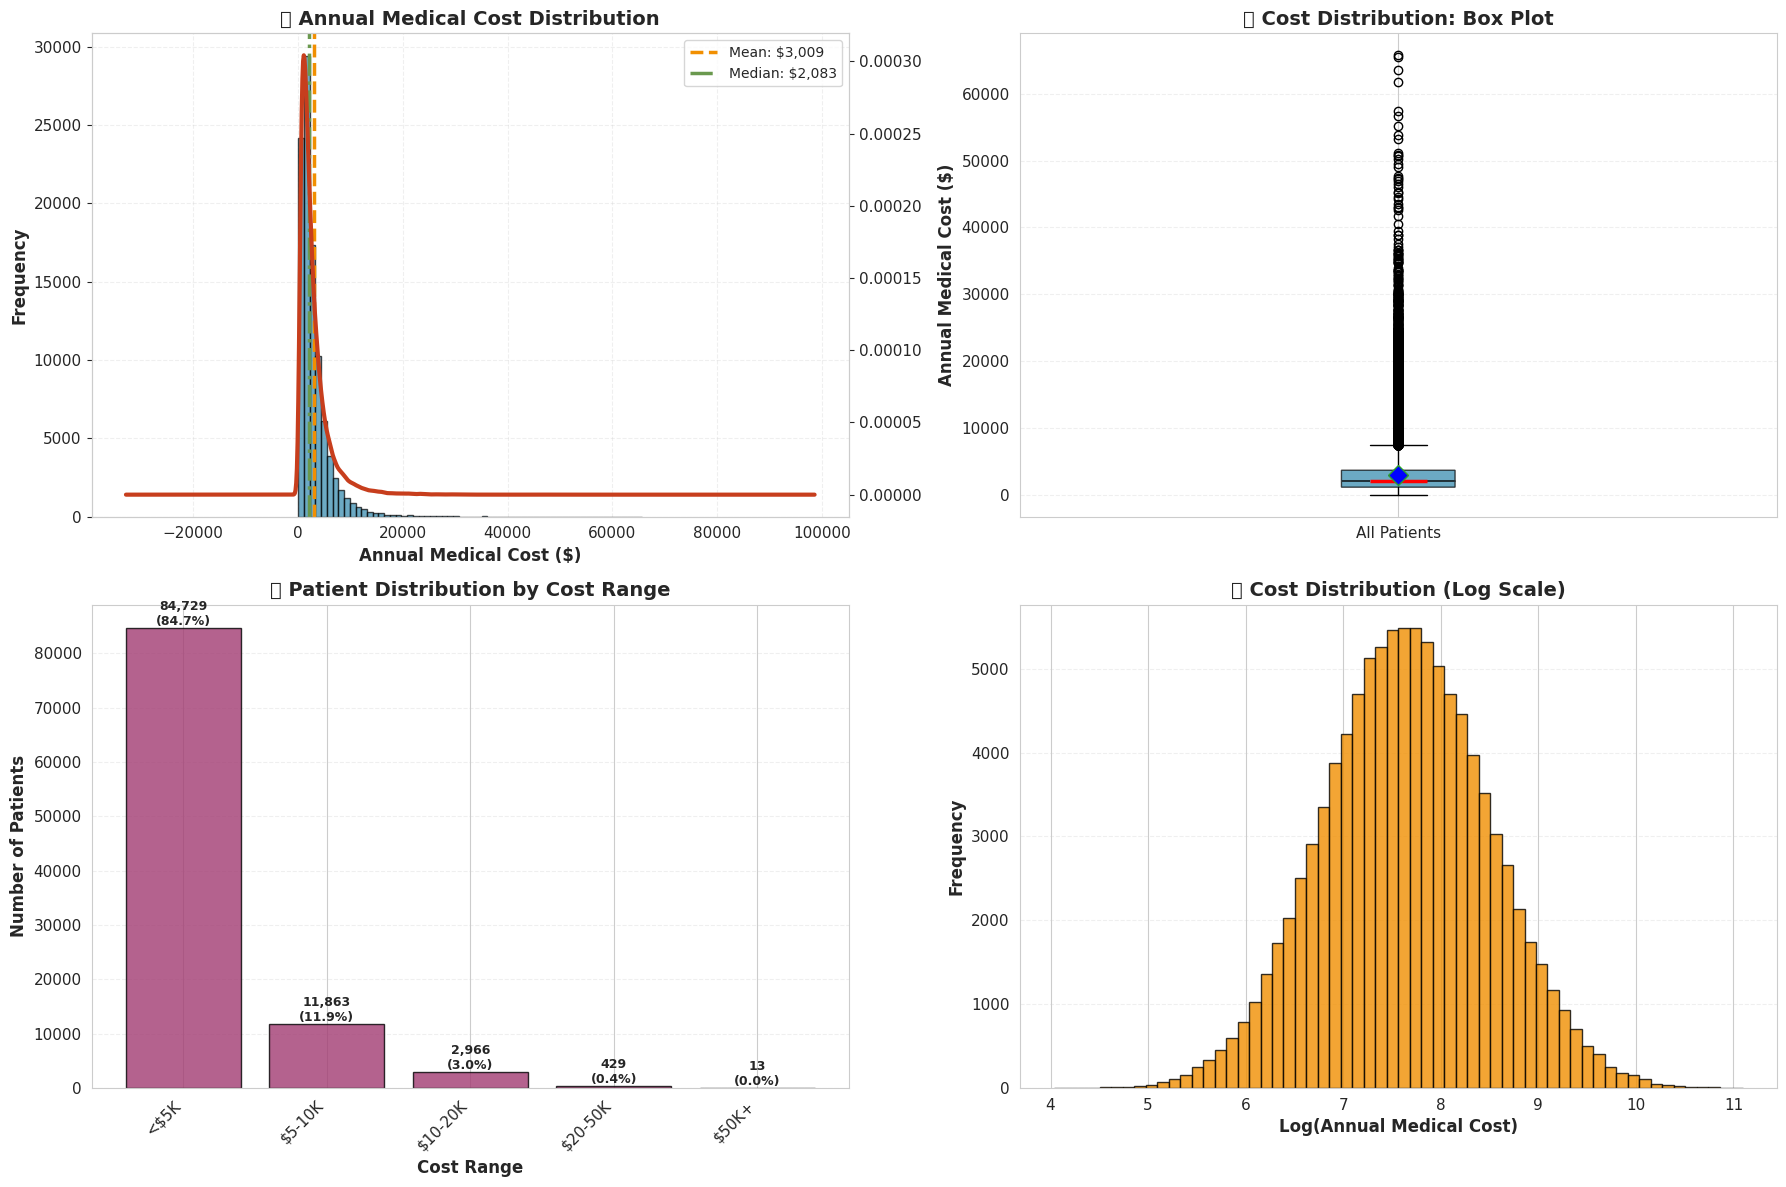

💡 KEY INSIGHTS: Annual Medical Cost Distribution
✓ Average annual cost: $3,009.45
✓ Median annual cost: $2,082.57
✓ Cost standard deviation: $3,127.46
✓ Distribution is right-skewed (skewness: 4.03)
✓ High-cost patients (>$50K): 13 (0.0%)
✓ Low-cost patients (<$5K): 84,729 (84.7%)
✓ Wide cost variation indicates diverse patient populations and healthcare needs


In [30]:
# EDA #1: Annual Medical Cost Distribution - Understanding Our Target
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-left: Histogram with KDE
axes[0,0].hist(df['annual_medical_cost'], bins=60, alpha=0.7, color='#2E86AB', edgecolor='black')
df['annual_medical_cost'].plot(kind='kde', ax=axes[0,0], color='#C73E1D', linewidth=3, secondary_y=True)
axes[0,0].axvline(df['annual_medical_cost'].mean(), color='#F18F01', linestyle='--', linewidth=2.5,
                 label=f'Mean: ${df["annual_medical_cost"].mean():,.0f}')
axes[0,0].axvline(df['annual_medical_cost'].median(), color='#6A994E', linestyle='-.', linewidth=2.5,
                 label=f'Median: ${df["annual_medical_cost"].median():,.0f}')
axes[0,0].set_xlabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0,0].set_title('💰 Annual Medical Cost Distribution', fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(alpha=0.3, linestyle='--')

# Top-right: Box plot
bp = axes[0,1].boxplot([df['annual_medical_cost']], patch_artist=True, notch=True, showmeans=True,
                       boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2.5),
                       meanprops=dict(marker='D', markerfacecolor='blue', markersize=10))
axes[0,1].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
axes[0,1].set_title('📊 Cost Distribution: Box Plot', fontsize=14, fontweight='bold')
axes[0,1].set_xticklabels(['All Patients'])
axes[0,1].grid(alpha=0.3, axis='y', linestyle='--')

# Bottom-left: Cost ranges - FIXED
max_cost = df['annual_medical_cost'].max()
if max_cost > 100000:
    cost_bins = [0, 5000, 10000, 20000, 50000, 100000, max_cost + 1]
    cost_labels = ['<$5K', '$5-10K', '$10-20K', '$20-50K', '$50-100K', '>$100K']
else:
    cost_bins = [0, 5000, 10000, 20000, 50000, max_cost + 1]
    cost_labels = ['<$5K', '$5-10K', '$10-20K', '$20-50K', f'${50}K+']

df['cost_range'] = pd.cut(df['annual_medical_cost'], bins=cost_bins, labels=cost_labels)
range_counts = df['cost_range'].value_counts().sort_index()

bars = axes[1,0].bar(range(len(range_counts)), range_counts.values, color='#A23B72',
                    edgecolor='black', alpha=0.8)
axes[1,0].set_xlabel('Cost Range', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
axes[1,0].set_title('📈 Patient Distribution by Cost Range', fontsize=14, fontweight='bold')
axes[1,0].set_xticks(range(len(range_counts)))
axes[1,0].set_xticklabels(range_counts.index, rotation=45, ha='right')
axes[1,0].grid(alpha=0.3, axis='y', linestyle='--')

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                  f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                  ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bottom-right: Log scale distribution
axes[1,1].hist(np.log1p(df['annual_medical_cost']), bins=60, color='#F18F01',
              edgecolor='black', alpha=0.8)
axes[1,1].set_xlabel('Log(Annual Medical Cost)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1,1].set_title('📉 Cost Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1,1].grid(alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Key insights
print("="*70)
print("💡 KEY INSIGHTS: Annual Medical Cost Distribution")
print("="*70)
print(f"✓ Average annual cost: ${df['annual_medical_cost'].mean():,.2f}")
print(f"✓ Median annual cost: ${df['annual_medical_cost'].median():,.2f}")
print(f"✓ Cost standard deviation: ${df['annual_medical_cost'].std():,.2f}")
print(f"✓ Distribution is {'right-skewed' if df['annual_medical_cost'].skew() > 0 else 'left-skewed'} (skewness: {df['annual_medical_cost'].skew():.2f})")
print(f"✓ High-cost patients (>$50K): {len(df[df['annual_medical_cost'] > 50000]):,} ({len(df[df['annual_medical_cost'] > 50000])/len(df)*100:.1f}%)")
print(f"✓ Low-cost patients (<$5K): {len(df[df['annual_medical_cost'] < 5000]):,} ({len(df[df['annual_medical_cost'] < 5000])/len(df)*100:.1f}%)")
print(f"✓ Wide cost variation indicates diverse patient populations and healthcare needs")
print("="*70)

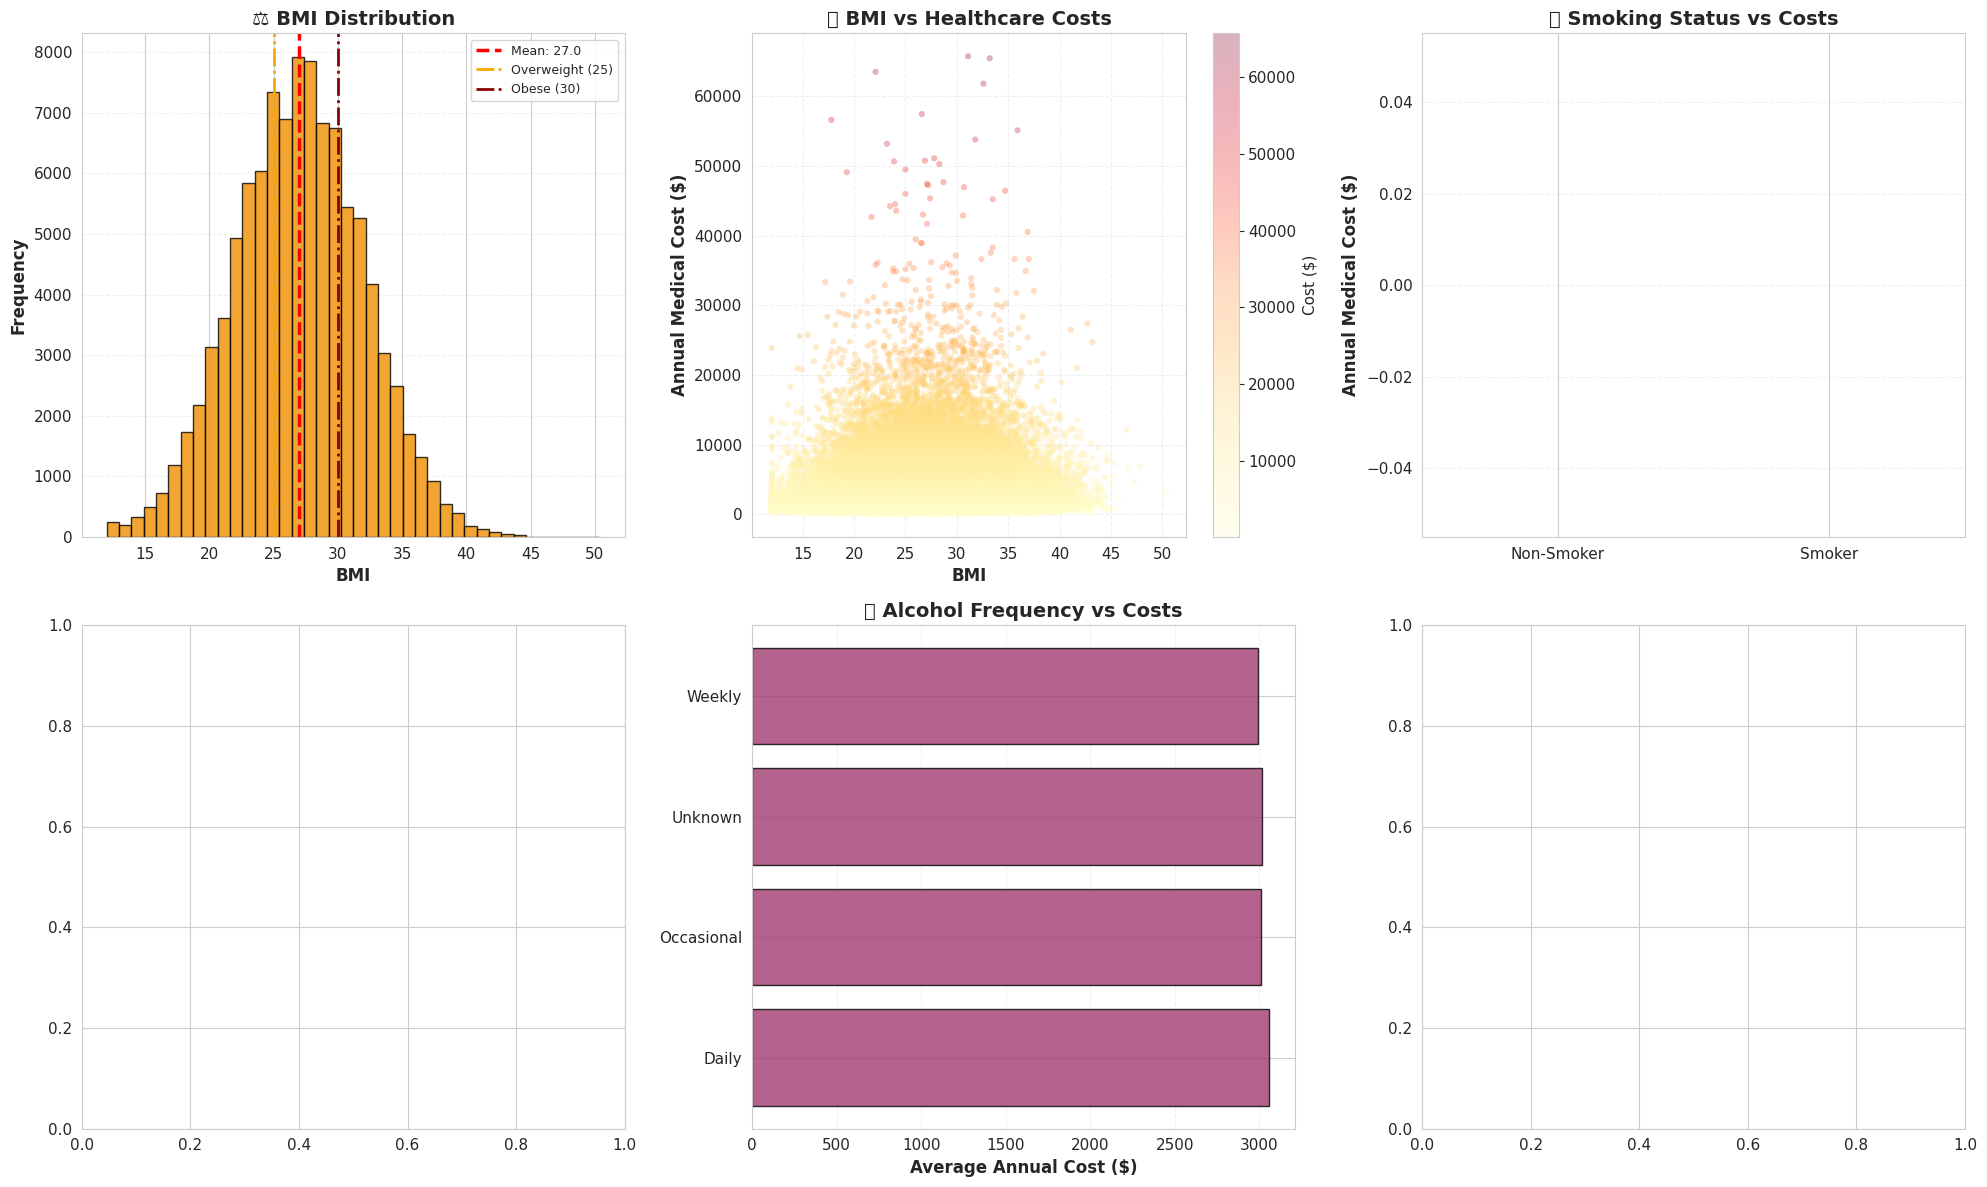

💡 KEY INSIGHTS: Lifestyle Factors
✓ BMI-Cost correlation: +0.043
✓ Average BMI: 27.0
✓ Smokers average cost: $nan
✓ Non-smokers average cost: $nan
✓ Smoking cost premium: $nan (nan% higher)
✓ Lifestyle choices significantly impact healthcare costs!


In [31]:
# EDA #3: Lifestyle Factors and Healthcare Costs
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Top-left: BMI distribution
axes[0,0].hist(df['bmi'], bins=40, color='#F18F01', edgecolor='black', alpha=0.8)
axes[0,0].axvline(df['bmi'].mean(), color='red', linestyle='--', linewidth=2.5,
                 label=f'Mean: {df["bmi"].mean():.1f}')
axes[0,0].axvline(25, color='orange', linestyle='-.', linewidth=2, label='Overweight (25)')
axes[0,0].axvline(30, color='darkred', linestyle='-.', linewidth=2, label='Obese (30)')
axes[0,0].set_xlabel('BMI', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0,0].set_title('⚖️ BMI Distribution', fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(alpha=0.3, axis='y', linestyle='--')

# Top-middle: BMI vs Cost scatter
scatter = axes[0,1].scatter(df['bmi'], df['annual_medical_cost'],
                           alpha=0.3, s=20, c=df['annual_medical_cost'],
                           cmap='YlOrRd', edgecolors='none')
axes[0,1].set_xlabel('BMI', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
axes[0,1].set_title('📈 BMI vs Healthcare Costs', fontsize=14, fontweight='bold')
axes[0,1].grid(alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=axes[0,1], label='Cost ($)')

# Top-right: Smoking impact
if 'smoker' in df.columns:
    smoker_costs = [df[df['smoker'] == 0]['annual_medical_cost'],
                   df[df['smoker'] == 1]['annual_medical_cost']]
    bp = axes[0,2].boxplot(smoker_costs, labels=['Non-Smoker', 'Smoker'],
                          patch_artist=True, notch=True)
    for patch, color in zip(bp['boxes'], ['#6A994E', '#C73E1D']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[0,2].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
    axes[0,2].set_title('🚬 Smoking Status vs Costs', fontsize=14, fontweight='bold')
    axes[0,2].grid(alpha=0.3, axis='y', linestyle='--')

# Bottom-left: Exercise frequency impact
if 'exercise_frequency' in df.columns:
    exercise_cost = df.groupby('exercise_frequency')['annual_medical_cost'].mean().sort_index()
    bars = axes[1,0].bar(range(len(exercise_cost)), exercise_cost.values,
                        color='#2E86AB', edgecolor='black', alpha=0.8)
    axes[1,0].set_xlabel('Exercise Frequency (days/week)', fontsize=12, fontweight='bold')
    axes[1,0].set_ylabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
    axes[1,0].set_title('🏃 Exercise Frequency vs Costs', fontsize=14, fontweight='bold')
    axes[1,0].set_xticks(range(len(exercise_cost)))
    axes[1,0].set_xticklabels(exercise_cost.index)
    axes[1,0].grid(alpha=0.3, axis='y', linestyle='--')

    for bar in bars:
        height = bar.get_height()
        axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                      f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Bottom-middle: Alcohol frequency
if 'alcohol_freq' in df.columns:
    alcohol_cost = df.groupby('alcohol_freq')['annual_medical_cost'].mean()
    bars = axes[1,1].barh(range(len(alcohol_cost)), alcohol_cost.values,
                         color='#A23B72', edgecolor='black', alpha=0.8)
    axes[1,1].set_yticks(range(len(alcohol_cost)))
    axes[1,1].set_yticklabels(alcohol_cost.index)
    axes[1,1].set_xlabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
    axes[1,1].set_title('🍺 Alcohol Frequency vs Costs', fontsize=14, fontweight='bold')
    axes[1,1].grid(alpha=0.3, axis='x', linestyle='--')

# Bottom-right: Sleep hours impact
if 'sleep_hours' in df.columns:
    sleep_cost = df.groupby('sleep_hours')['annual_medical_cost'].mean().sort_index()
    axes[1,2].plot(sleep_cost.index, sleep_cost.values, marker='o', linewidth=2.5,
                  markersize=8, color='#F18F01')
    axes[1,2].set_xlabel('Sleep Hours per Night', fontsize=12, fontweight='bold')
    axes[1,2].set_ylabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
    axes[1,2].set_title('😴 Sleep Duration vs Costs', fontsize=14, fontweight='bold')
    axes[1,2].grid(alpha=0.3, linestyle='--')
    axes[1,2].axvspan(7, 9, alpha=0.2, color='green', label='Recommended (7-9h)')
    axes[1,2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Lifestyle statistics
bmi_corr = df['bmi'].corr(df['annual_medical_cost'])
print("="*70)
print("💡 KEY INSIGHTS: Lifestyle Factors")
print("="*70)
print(f"✓ BMI-Cost correlation: {bmi_corr:+.3f}")
print(f"✓ Average BMI: {df['bmi'].mean():.1f}")

if 'smoker' in df.columns:
    smoker_avg = df[df['smoker'] == 1]['annual_medical_cost'].mean()
    nonsmoker_avg = df[df['smoker'] == 0]['annual_medical_cost'].mean()
    print(f"✓ Smokers average cost: ${smoker_avg:,.2f}")
    print(f"✓ Non-smokers average cost: ${nonsmoker_avg:,.2f}")
    print(f"✓ Smoking cost premium: ${smoker_avg - nonsmoker_avg:,.2f} ({(smoker_avg/nonsmoker_avg - 1)*100:.1f}% higher)")

if 'exercise_frequency' in df.columns:
    print(f"✓ Exercise frequency range: {df['exercise_frequency'].min():.0f} - {df['exercise_frequency'].max():.0f} days/week")
    print(f"✓ Patients exercising 5+ days/week: {(df['exercise_frequency'] >= 5).sum():,} ({(df['exercise_frequency'] >= 5).mean()*100:.1f}%)")

print(f"✓ Lifestyle choices significantly impact healthcare costs!")
print("="*70)

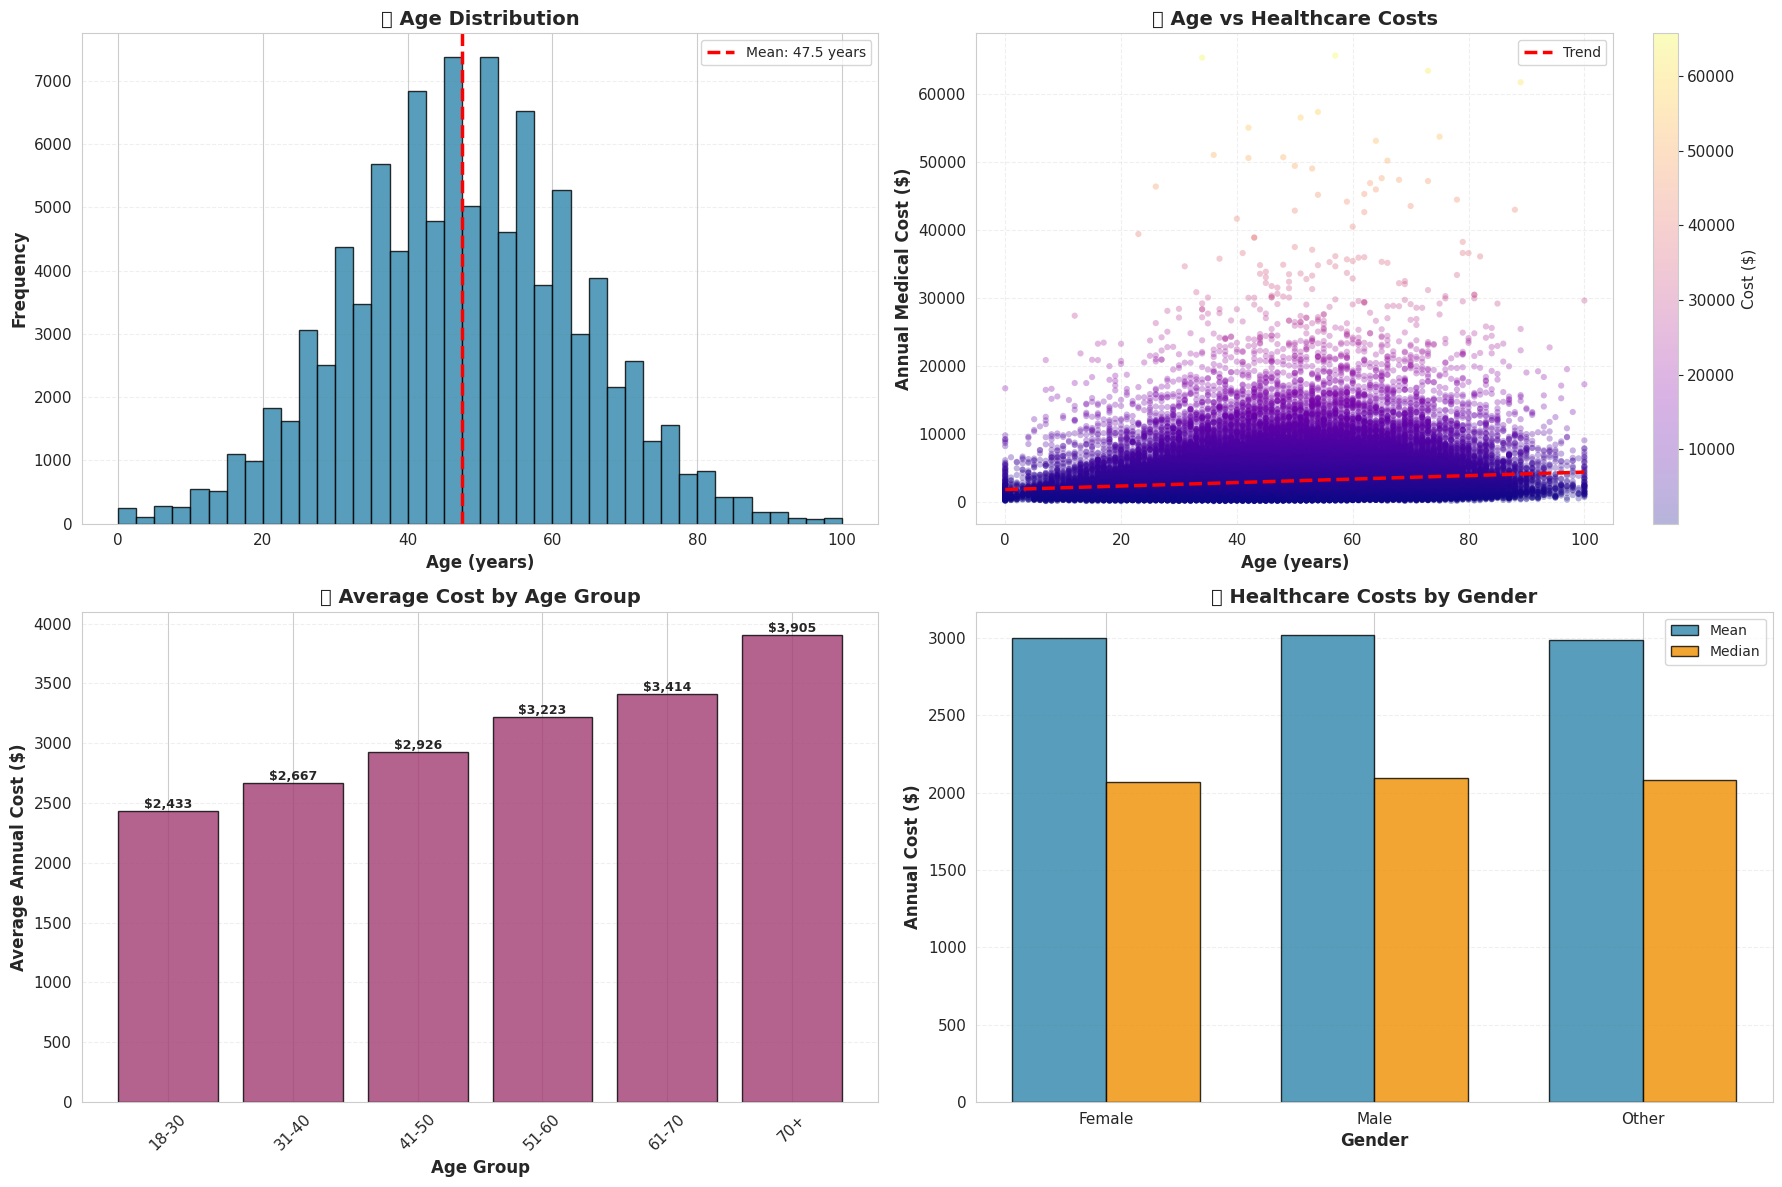

💡 KEY INSIGHTS: Age & Demographics
✓ Age-Cost correlation: +0.131
✓ Mean age: 47.5 years
✓ Age range: 0 - 100 years
✓ Patients 60+: 22,816 (22.8%)
✓ Cost increase per decade: $289.46
✓ Average cost (Female): $3,000.03
✓ Average cost (Male): $3,019.94
✓ Age is a strong predictor of healthcare costs!


In [32]:
# EDA #4: Age and Demographic Factors
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-left: Age distribution
axes[0,0].hist(df['age'], bins=40, color='#2E86AB', edgecolor='black', alpha=0.8)
axes[0,0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2.5,
                 label=f'Mean: {df["age"].mean():.1f} years')
axes[0,0].set_xlabel('Age (years)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0,0].set_title('👤 Age Distribution', fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(alpha=0.3, axis='y', linestyle='--')

# Top-right: Age vs Cost
scatter = axes[0,1].scatter(df['age'], df['annual_medical_cost'],
                           alpha=0.3, s=20, c=df['annual_medical_cost'],
                           cmap='plasma', edgecolors='none')
axes[0,1].set_xlabel('Age (years)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
axes[0,1].set_title('📈 Age vs Healthcare Costs', fontsize=14, fontweight='bold')
axes[0,1].grid(alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=axes[0,1], label='Cost ($)')

# Add trend line
z = np.polyfit(df['age'], df['annual_medical_cost'], 1)
p = np.poly1d(z)
axes[0,1].plot(sorted(df['age']), p(sorted(df['age'])),
              "r--", linewidth=2.5, label='Trend')
axes[0,1].legend(fontsize=10)

# Bottom-left: Cost by age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 70, 100],
                         labels=['18-30', '31-40', '41-50', '51-60', '61-70', '70+'])
age_cost = df.groupby('age_group')['annual_medical_cost'].mean()

bars = axes[1,0].bar(range(len(age_cost)), age_cost.values,
                    color='#A23B72', edgecolor='black', alpha=0.8)
axes[1,0].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
axes[1,0].set_title('💰 Average Cost by Age Group', fontsize=14, fontweight='bold')
axes[1,0].set_xticks(range(len(age_cost)))
axes[1,0].set_xticklabels(age_cost.index, rotation=45)
axes[1,0].grid(alpha=0.3, axis='y', linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                  f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bottom-right: Gender comparison
if 'sex' in df.columns:
    gender_data = df.groupby('sex')['annual_medical_cost'].agg(['mean', 'median', 'std'])

    x = np.arange(len(gender_data))
    width = 0.35

    bars1 = axes[1,1].bar(x - width/2, gender_data['mean'], width,
                         label='Mean', color='#2E86AB', edgecolor='black', alpha=0.8)
    bars2 = axes[1,1].bar(x + width/2, gender_data['median'], width,
                         label='Median', color='#F18F01', edgecolor='black', alpha=0.8)

    axes[1,1].set_xlabel('Gender', fontsize=12, fontweight='bold')
    axes[1,1].set_ylabel('Annual Cost ($)', fontsize=12, fontweight='bold')
    axes[1,1].set_title('👥 Healthcare Costs by Gender', fontsize=14, fontweight='bold')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(gender_data.index)
    axes[1,1].legend(fontsize=10)
    axes[1,1].grid(alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Age statistics
age_corr = df['age'].corr(df['annual_medical_cost'])
print("="*70)
print("💡 KEY INSIGHTS: Age & Demographics")
print("="*70)
print(f"✓ Age-Cost correlation: {age_corr:+.3f}")
print(f"✓ Mean age: {df['age'].mean():.1f} years")
print(f"✓ Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")
print(f"✓ Patients 60+: {(df['age'] >= 60).sum():,} ({(df['age'] >= 60).mean()*100:.1f}%)")
print(f"✓ Cost increase per decade: ${(df[df['age'] >= 60]['annual_medical_cost'].mean() - df[df['age'] < 30]['annual_medical_cost'].mean()) / 4:,.2f}")

if 'sex' in df.columns:
    for gender in df['sex'].unique()[:2]:  # Show top 2 genders
        avg_cost = df[df['sex'] == gender]['annual_medical_cost'].mean()
        print(f"✓ Average cost ({gender}): ${avg_cost:,.2f}")

print(f"✓ Age is a strong predictor of healthcare costs!")
print("="*70)

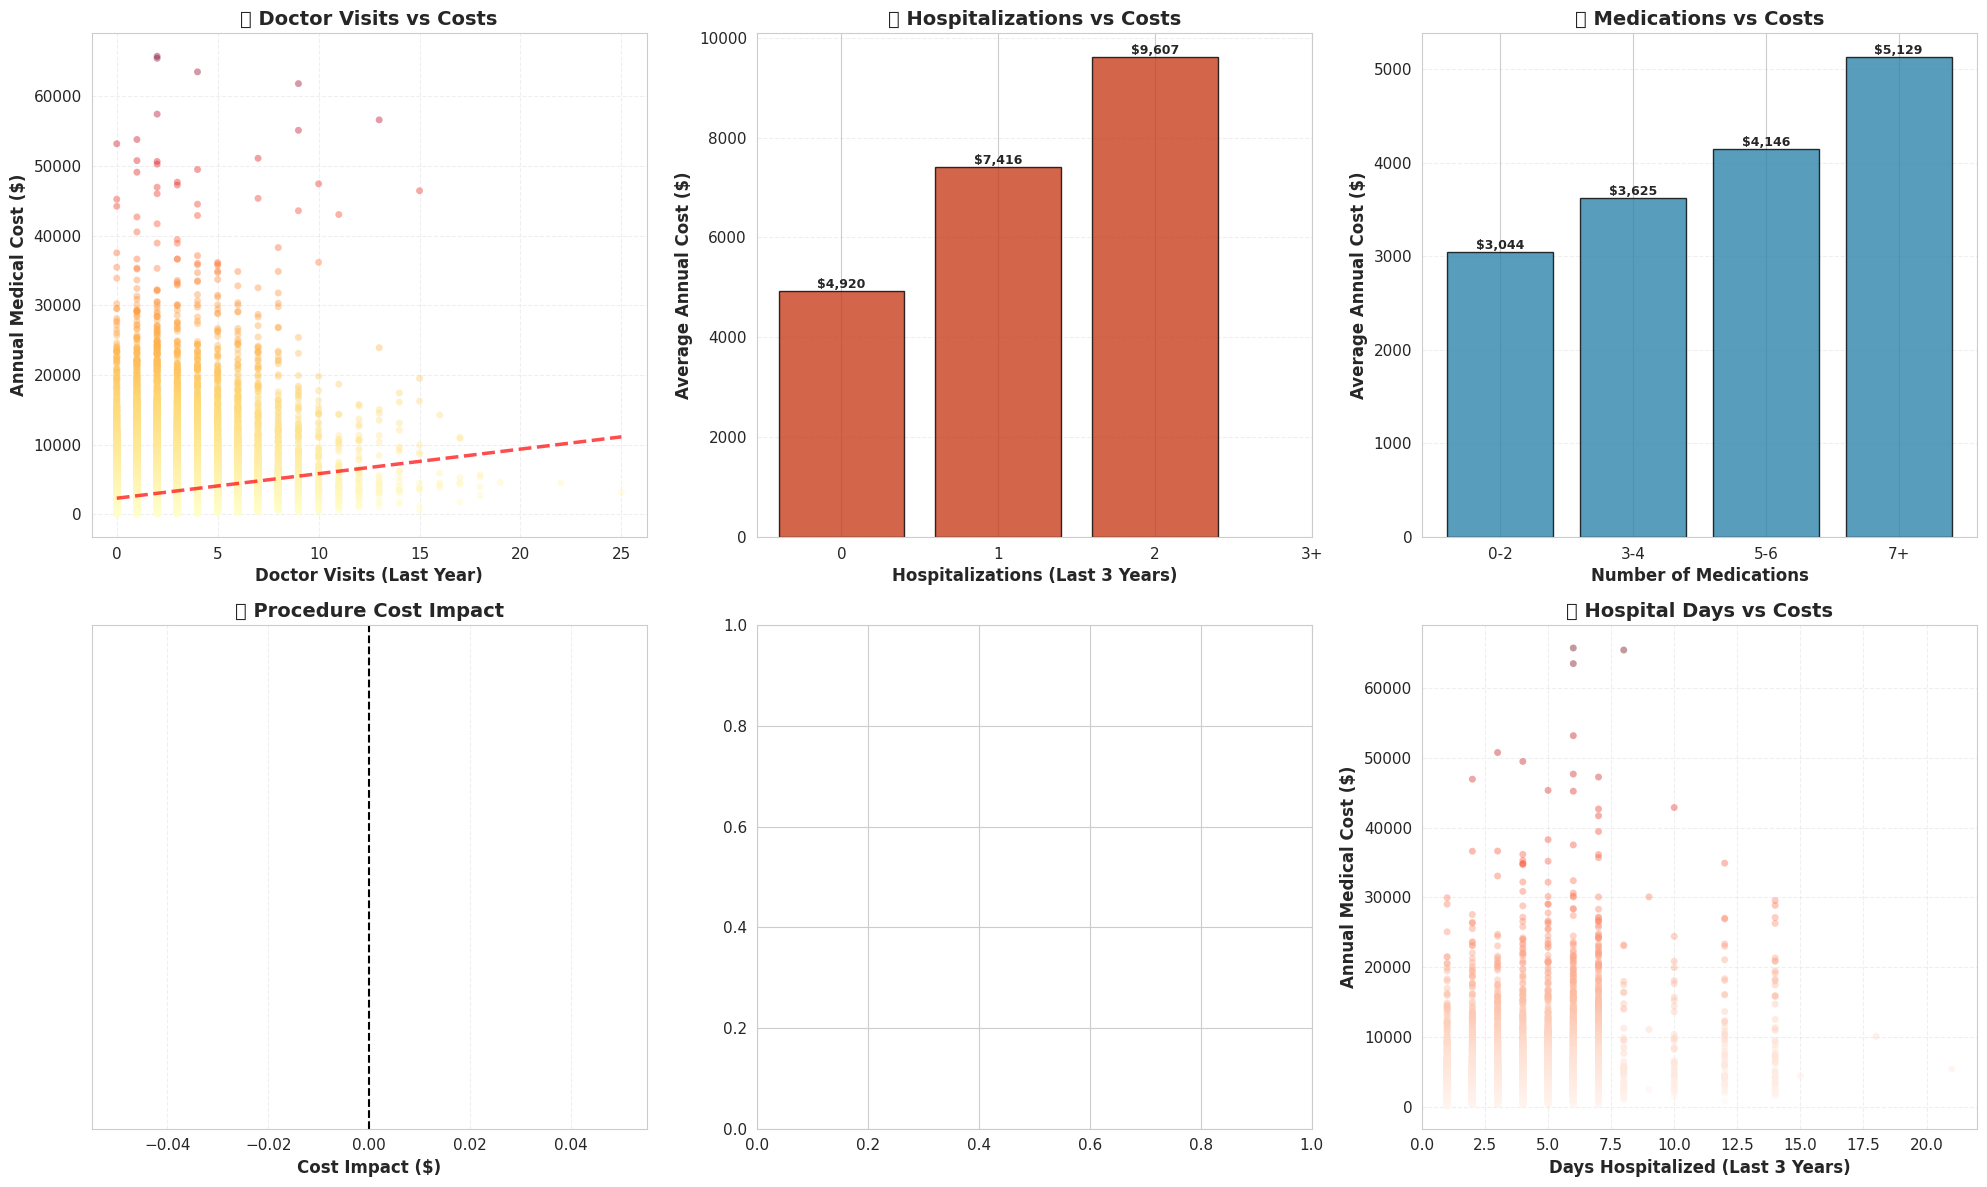

💡 KEY INSIGHTS: Healthcare Utilization
✓ Doctor visits - Cost correlation: +0.196
✓ Medication count - Cost correlation: +0.113
✓ Average visits per year: 1.9
✓ Average medications: 1.2
✓ Patients with hospitalizations: 8,969 (9.0%)
✓ Healthcare utilization is STRONGLY predictive of costs!


In [33]:
# EDA #5: Healthcare Utilization and Costs
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Top-left: Doctor visits vs costs
scatter = axes[0,0].scatter(df['visits_last_year'], df['annual_medical_cost'],
                           alpha=0.4, s=25, c=df['annual_medical_cost'],
                           cmap='YlOrRd', edgecolors='none')
axes[0,0].set_xlabel('Doctor Visits (Last Year)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
axes[0,0].set_title('🏥 Doctor Visits vs Costs', fontsize=14, fontweight='bold')
axes[0,0].grid(alpha=0.3, linestyle='--')

# Add trend line
z = np.polyfit(df['visits_last_year'], df['annual_medical_cost'], 1)
p = np.poly1d(z)
axes[0,0].plot(sorted(df['visits_last_year']), p(sorted(df['visits_last_year'])),
              "r--", linewidth=2.5, alpha=0.7)

# Top-middle: Hospitalizations impact
hosp_bins = [0, 1, 2, 3, df['hospitalizations_last_3yrs'].max() + 1]
hosp_labels = ['0', '1', '2', '3+']
df['hosp_category'] = pd.cut(df['hospitalizations_last_3yrs'], bins=hosp_bins, labels=hosp_labels)
hosp_cost = df.groupby('hosp_category')['annual_medical_cost'].mean()

bars = axes[0,1].bar(range(len(hosp_cost)), hosp_cost.values,
                    color='#C73E1D', edgecolor='black', alpha=0.8)
axes[0,1].set_xlabel('Hospitalizations (Last 3 Years)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
axes[0,1].set_title('🏨 Hospitalizations vs Costs', fontsize=14, fontweight='bold')
axes[0,1].set_xticks(range(len(hosp_cost)))
axes[0,1].set_xticklabels(hosp_cost.index)
axes[0,1].grid(alpha=0.3, axis='y', linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                  f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Top-right: Medication count impact
med_bins = [0, 2, 4, 6, df['medication_count'].max() + 1]
med_labels = ['0-2', '3-4', '5-6', '7+']
df['med_category'] = pd.cut(df['medication_count'], bins=med_bins, labels=med_labels)
med_cost = df.groupby('med_category')['annual_medical_cost'].mean()

bars = axes[0,2].bar(range(len(med_cost)), med_cost.values,
                    color='#2E86AB', edgecolor='black', alpha=0.8)
axes[0,2].set_xlabel('Number of Medications', fontsize=12, fontweight='bold')
axes[0,2].set_ylabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
axes[0,2].set_title('💊 Medications vs Costs', fontsize=14, fontweight='bold')
axes[0,2].set_xticks(range(len(med_cost)))
axes[0,2].set_xticklabels(med_cost.index)
axes[0,2].grid(alpha=0.3, axis='y', linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[0,2].text(bar.get_x() + bar.get_width()/2., height,
                  f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bottom-left: Procedure types
procedures = ['proc_imaging', 'proc_surgery', 'proc_psycho', 'proc_lab']
proc_costs = {}

for proc in procedures:
    if proc in df.columns:
        has_proc = df[df[proc] == 1]['annual_medical_cost'].mean()
        no_proc = df[df[proc] == 0]['annual_medical_cost'].mean()
        proc_costs[proc.replace('proc_', '').title()] = has_proc - no_proc

proc_impact = pd.Series(proc_costs).sort_values(ascending=True)
colors_proc = ['#6A994E' if x > 0 else '#C73E1D' for x in proc_impact.values]

axes[1,0].barh(range(len(proc_impact)), proc_impact.values, color=colors_proc,
              edgecolor='black', alpha=0.8)
axes[1,0].set_yticks(range(len(proc_impact)))
axes[1,0].set_yticklabels(proc_impact.index)
axes[1,0].set_xlabel('Cost Impact ($)', fontsize=12, fontweight='bold')
axes[1,0].set_title('🔬 Procedure Cost Impact', fontsize=14, fontweight='bold')
axes[1,0].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1,0].grid(alpha=0.3, axis='x', linestyle='--')

# Bottom-middle: Major surgery impact
if 'had_major' in df.columns:
    major_costs = [df[df['had_major'] == 0]['annual_medical_cost'],
                   df[df['had_major'] == 1]['annual_medical_cost']]
    bp = axes[1,1].boxplot(major_costs, labels=['No Major Surgery', 'Had Major Surgery'],
                          patch_artist=True, notch=True)
    for patch, color in zip(bp['boxes'], ['#6A994E', '#C73E1D']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[1,1].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
    axes[1,1].set_title('⚕️ Major Surgery Impact', fontsize=14, fontweight='bold')
    axes[1,1].tick_params(axis='x', rotation=15)
    axes[1,1].grid(alpha=0.3, axis='y', linestyle='--')

# Bottom-right: Days hospitalized
if 'days_hospitalized_last_3yrs' in df.columns:
    # Only plot for patients with hospitalizations
    hosp_days = df[df['days_hospitalized_last_3yrs'] > 0]
    if len(hosp_days) > 0:
        scatter = axes[1,2].scatter(hosp_days['days_hospitalized_last_3yrs'],
                                   hosp_days['annual_medical_cost'],
                                   alpha=0.4, s=25, c=hosp_days['annual_medical_cost'],
                                   cmap='Reds', edgecolors='none')
        axes[1,2].set_xlabel('Days Hospitalized (Last 3 Years)', fontsize=12, fontweight='bold')
        axes[1,2].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
        axes[1,2].set_title('📅 Hospital Days vs Costs', fontsize=14, fontweight='bold')
        axes[1,2].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Utilization statistics
visits_corr = df['visits_last_year'].corr(df['annual_medical_cost'])
med_corr = df['medication_count'].corr(df['annual_medical_cost'])

print("="*70)
print("💡 KEY INSIGHTS: Healthcare Utilization")
print("="*70)
print(f"✓ Doctor visits - Cost correlation: {visits_corr:+.3f}")
print(f"✓ Medication count - Cost correlation: {med_corr:+.3f}")
print(f"✓ Average visits per year: {df['visits_last_year'].mean():.1f}")
print(f"✓ Average medications: {df['medication_count'].mean():.1f}")
print(f"✓ Patients with hospitalizations: {(df['hospitalizations_last_3yrs'] > 0).sum():,} ({(df['hospitalizations_last_3yrs'] > 0).mean()*100:.1f}%)")

if 'had_major' in df.columns:
    major_avg = df[df['had_major'] == 1]['annual_medical_cost'].mean()
    no_major_avg = df[df['had_major'] == 0]['annual_medical_cost'].mean()
    print(f"✓ Major surgery cost premium: ${major_avg - no_major_avg:,.2f}")

print(f"✓ Healthcare utilization is STRONGLY predictive of costs!")
print("="*70)

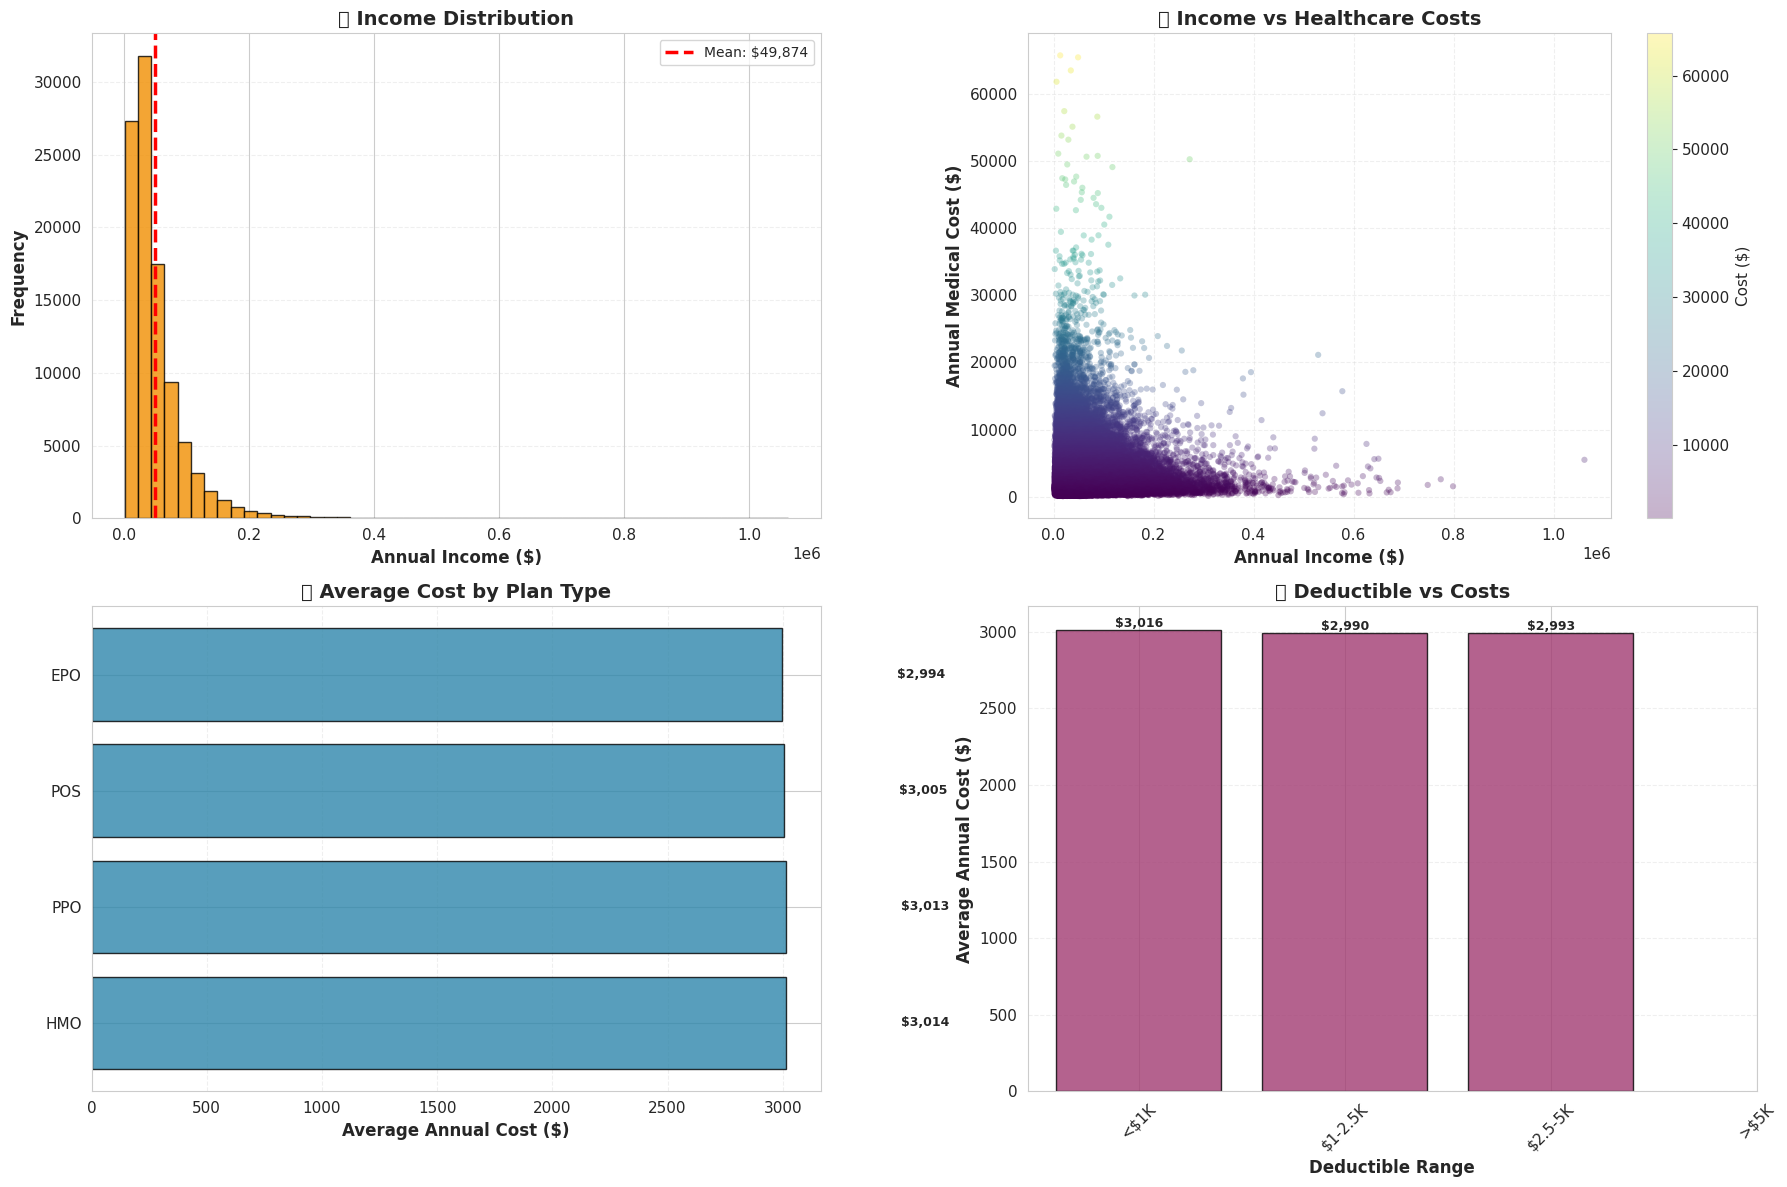

💡 KEY INSIGHTS: Income & Insurance
✓ Income - Cost correlation: -0.006
✓ Mean income: $49,873.90
✓ Median income: $36,200.00
✓ Income range: $1,100 - $1,061,800

📋 Most Common Plan Types:
   1. PPO: 35,167 patients (35.2%)
   2. HMO: 34,723 patients (34.7%)
   3. EPO: 15,121 patients (15.1%)

✓ Average deductible: $1,226.72
✓ Income level influences healthcare access and utilization patterns


In [34]:
# EDA #6: Income and Insurance Factors
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-left: Income distribution
axes[0,0].hist(df['income'], bins=50, color='#F18F01', edgecolor='black', alpha=0.8)
axes[0,0].axvline(df['income'].mean(), color='red', linestyle='--', linewidth=2.5,
                 label=f'Mean: ${df["income"].mean():,.0f}')
axes[0,0].set_xlabel('Annual Income ($)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0,0].set_title('💵 Income Distribution', fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(alpha=0.3, axis='y', linestyle='--')

# Top-right: Income vs Cost
scatter = axes[0,1].scatter(df['income'], df['annual_medical_cost'],
                           alpha=0.3, s=20, c=df['annual_medical_cost'],
                           cmap='viridis', edgecolors='none')
axes[0,1].set_xlabel('Annual Income ($)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Annual Medical Cost ($)', fontsize=12, fontweight='bold')
axes[0,1].set_title('📊 Income vs Healthcare Costs', fontsize=14, fontweight='bold')
axes[0,1].grid(alpha=0.3, linestyle='--')
plt.colorbar(scatter, ax=axes[0,1], label='Cost ($)')

# Bottom-left: Plan type costs
if 'plan_type' in df.columns:
    plan_cost = df.groupby('plan_type')['annual_medical_cost'].mean().sort_values(ascending=False)
    bars = axes[1,0].barh(range(len(plan_cost)), plan_cost.values,
                         color='#2E86AB', edgecolor='black', alpha=0.8)
    axes[1,0].set_yticks(range(len(plan_cost)))
    axes[1,0].set_yticklabels(plan_cost.index)
    axes[1,0].set_xlabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
    axes[1,0].set_title('📋 Average Cost by Plan Type', fontsize=14, fontweight='bold')
    axes[1,0].grid(alpha=0.3, axis='x', linestyle='--')

    for i, bar in enumerate(bars):
        width = bar.get_width()
        axes[1,0].text(width + 500, bar.get_y() + bar.get_height()/2,
                      f'${width:,.0f}', ha='left', va='center', fontsize=9, fontweight='bold')

# Bottom-right: Deductible analysis
if 'deductible' in df.columns:
    # Create deductible categories
    deduct_bins = [0, 1000, 2500, 5000, df['deductible'].max() + 1]
    deduct_labels = ['<$1K', '$1-2.5K', '$2.5-5K', '>$5K']
    df['deduct_category'] = pd.cut(df['deductible'], bins=deduct_bins, labels=deduct_labels)

    deduct_cost = df.groupby('deduct_category')['annual_medical_cost'].mean()
    bars = axes[1,1].bar(range(len(deduct_cost)), deduct_cost.values,
                        color='#A23B72', edgecolor='black', alpha=0.8)
    axes[1,1].set_xlabel('Deductible Range', fontsize=12, fontweight='bold')
    axes[1,1].set_ylabel('Average Annual Cost ($)', fontsize=12, fontweight='bold')
    axes[1,1].set_title('💳 Deductible vs Costs', fontsize=14, fontweight='bold')
    axes[1,1].set_xticks(range(len(deduct_cost)))
    axes[1,1].set_xticklabels(deduct_cost.index, rotation=45)
    axes[1,1].grid(alpha=0.3, axis='y', linestyle='--')

    for bar in bars:
        height = bar.get_height()
        axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                      f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Income statistics
income_corr = df['income'].corr(df['annual_medical_cost'])
print("="*70)
print("💡 KEY INSIGHTS: Income & Insurance")
print("="*70)
print(f"✓ Income - Cost correlation: {income_corr:+.3f}")
print(f"✓ Mean income: ${df['income'].mean():,.2f}")
print(f"✓ Median income: ${df['income'].median():,.2f}")
print(f"✓ Income range: ${df['income'].min():,.0f} - ${df['income'].max():,.0f}")

if 'plan_type' in df.columns:
    print(f"\n📋 Most Common Plan Types:")
    for i, (plan, count) in enumerate(df['plan_type'].value_counts().head(3).items(), 1):
        print(f"   {i}. {plan}: {count:,} patients ({count/len(df)*100:.1f}%)")

if 'deductible' in df.columns:
    print(f"\n✓ Average deductible: ${df['deductible'].mean():,.2f}")

print(f"✓ Income level influences healthcare access and utilization patterns")
print("="*70)

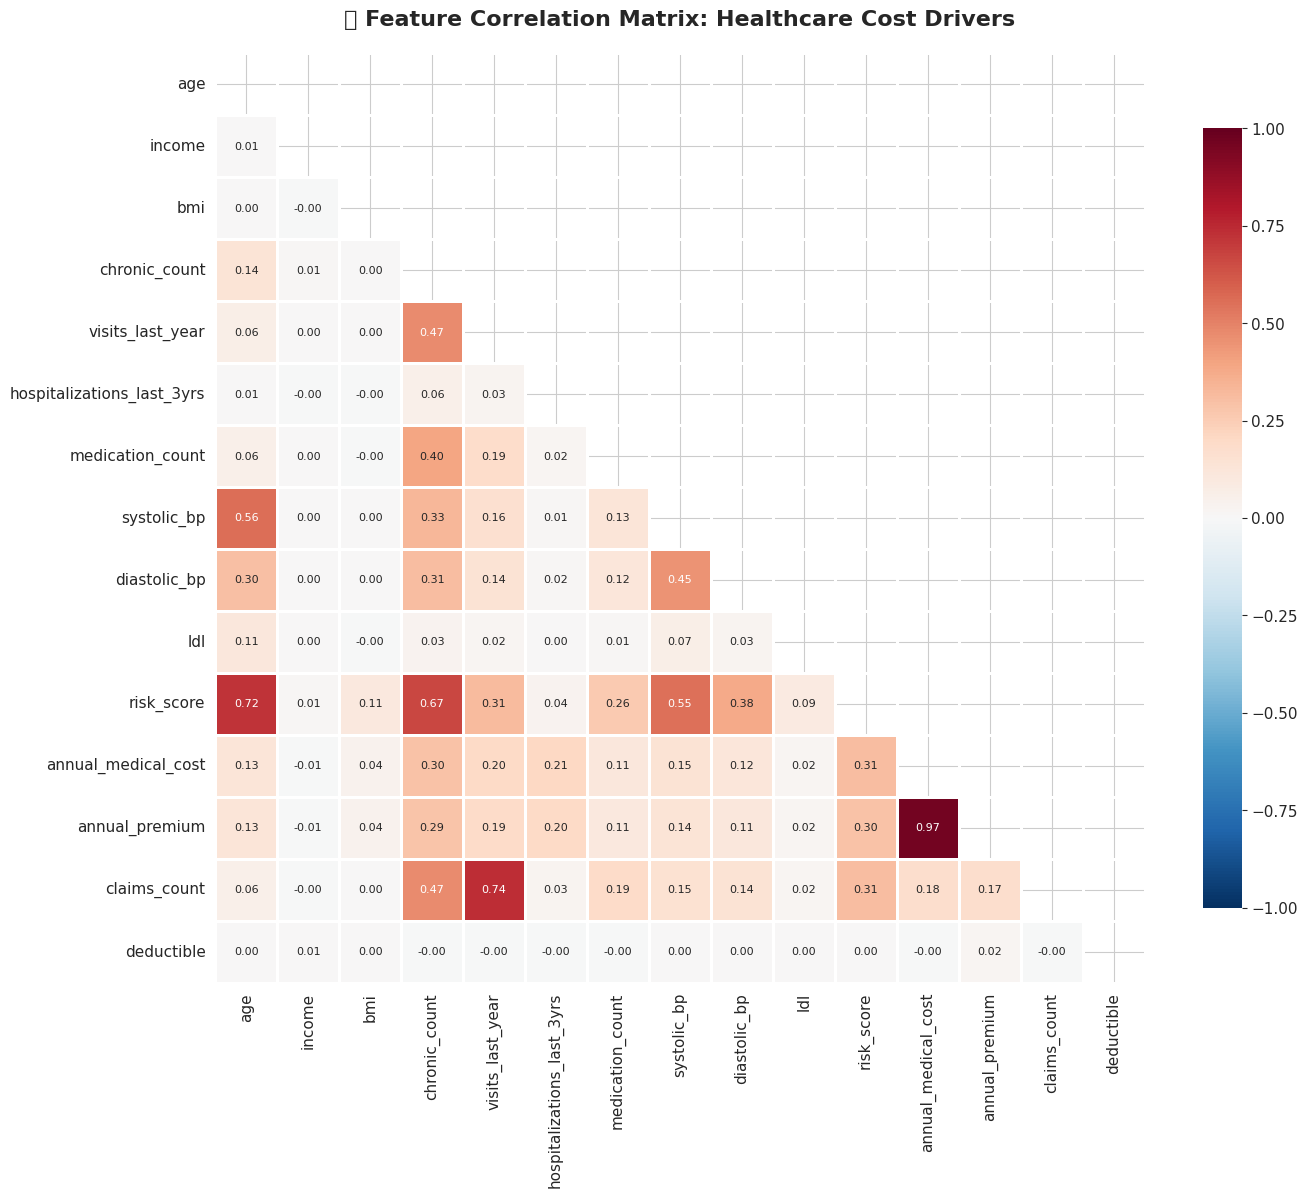

💡 KEY INSIGHTS: Feature Correlations with Medical Costs

🔝 TOP POSITIVE CORRELATIONS (Increase Costs):
    1. annual_premium.......................... +0.965
    2. risk_score.............................. +0.306
    3. chronic_count........................... +0.297
    4. hospitalizations_last_3yrs.............. +0.209
    5. visits_last_year........................ +0.196
    6. claims_count............................ +0.179
    7. systolic_bp............................. +0.145
    8. age..................................... +0.131
    9. diastolic_bp............................ +0.118
   10. medication_count........................ +0.113

🔻 TOP NEGATIVE CORRELATIONS (Decrease Costs):
    1. deductible.............................. -0.003
    2. income.................................. -0.006

📌 KEY TAKEAWAYS:
✓ Healthcare utilization metrics (visits, hospitalizations) are strongest predictors
✓ Chronic conditions and risk scores highly correlated with costs
✓ Age and clinical me

In [35]:
# EDA #7: Feature Correlation Matrix
# Select key numeric columns for correlation
key_features = ['age', 'income', 'bmi', 'chronic_count', 'visits_last_year',
                'hospitalizations_last_3yrs', 'medication_count', 'systolic_bp',
                'diastolic_bp', 'ldl', 'risk_score', 'annual_medical_cost',
                'annual_premium', 'claims_count', 'deductible']

# Filter to only existing columns
existing_features = [f for f in key_features if f in df.columns]
corr_matrix = df[existing_features].corr()

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax, annot_kws={'fontsize': 8})

ax.set_title('🔗 Feature Correlation Matrix: Healthcare Cost Drivers',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Key correlations with annual_medical_cost
cost_corr = corr_matrix['annual_medical_cost'].sort_values(ascending=False)

print("="*70)
print("💡 KEY INSIGHTS: Feature Correlations with Medical Costs")
print("="*70)
print("\n🔝 TOP POSITIVE CORRELATIONS (Increase Costs):")
for i, (feature, corr_val) in enumerate(cost_corr[1:11].items(), 1):
    print(f"   {i:2}. {feature:.<40} {corr_val:+.3f}")

print("\n🔻 TOP NEGATIVE CORRELATIONS (Decrease Costs):")
negative_corrs = cost_corr[cost_corr < 0].head(5)
for i, (feature, corr_val) in enumerate(negative_corrs.items(), 1):
    print(f"   {i:2}. {feature:.<40} {corr_val:+.3f}")

print("\n📌 KEY TAKEAWAYS:")
print("✓ Healthcare utilization metrics (visits, hospitalizations) are strongest predictors")
print("✓ Chronic conditions and risk scores highly correlated with costs")
print("✓ Age and clinical metrics (BP, LDL, HbA1c) show moderate correlation")
print("✓ Income shows weak/inverse relationship (higher income ≠ higher costs)")
print("="*70)

⚙️ Feature Engineering
Time to transform raw healthcare data into predictive powerhouses! We'll create sophisticated features that capture the complex relationships in medical costs.

Our Feature Engineering Strategy:
Healthcare Utilization Intensity: Visit rates, hospitalization severity
Health Risk Scores: Composite risk metrics from multiple conditions
Age-Health Interactions: How age amplifies health risks
Income-Insurance Features: Affordability and coverage gaps
Lifestyle Risk Factors: Combined BMI, smoking, exercise scores
Clinical Metrics: BP ratios, cholesterol risk levels
Utilization Efficiency: Cost per visit, procedures per patient
Temporal Features: Policy duration, changes over time
Categorical Encodings: Region, education, employment
Polynomial Features: Non-linear relationships
Let's engineer features that capture the nuances of healthcare economics! 🔧

In [36]:
# Create a copy for feature engineering
df_fe = df.copy()

print("="*70)
print("🔧 FEATURE ENGINEERING IN PROGRESS")
print("="*70)

# 1. HEALTHCARE UTILIZATION INTENSITY FEATURES
df_fe['visits_per_month'] = df_fe['visits_last_year'] / 12
df_fe['hosp_intensity'] = df_fe['hospitalizations_last_3yrs'] / 3  # Per year
df_fe['days_per_hospitalization'] = df_fe['days_hospitalized_last_3yrs'] / (df_fe['hospitalizations_last_3yrs'] + 1)

# Only create total_procedures if procedure columns exist
proc_cols = ['proc_imaging', 'proc_surgery', 'proc_psycho', 'proc_lab']
existing_proc_cols = [col for col in proc_cols if col in df_fe.columns]
if existing_proc_cols:
    df_fe['total_procedures'] = df_fe[existing_proc_cols].sum(axis=1)
else:
    df_fe['total_procedures'] = 0

df_fe['utilization_score'] = (df_fe['visits_last_year'] +
                               df_fe['hospitalizations_last_3yrs'] * 10 +
                               df_fe['medication_count'] * 2)
print("✓ Created healthcare utilization features")

# 2. HEALTH RISK COMPOSITE SCORES
chronic_conditions = ['hypertension', 'diabetes', 'cardiovascular']
existing_chronic = [col for col in chronic_conditions if col in df_fe.columns]
if existing_chronic:
    df_fe['cardiovascular_risk'] = df_fe[existing_chronic].sum(axis=1).clip(upper=3)
else:
    df_fe['cardiovascular_risk'] = 0

df_fe['complex_patient'] = (df_fe['chronic_count'] >= 3).astype(int)
df_fe['high_risk_patient'] = (df_fe['risk_score'] > df_fe['risk_score'].quantile(0.75)).astype(int)

critical_conds = ['cancer_history', 'kidney_disease', 'liver_disease']
existing_critical = [col for col in critical_conds if col in df_fe.columns]
if existing_critical:
    df_fe['critical_conditions'] = df_fe[existing_critical].sum(axis=1)
else:
    df_fe['critical_conditions'] = 0

print("✓ Created health risk composite scores")

# 3. AGE-HEALTH INTERACTION FEATURES
df_fe['age_chronic_interaction'] = df_fe['age'] * df_fe['chronic_count']
df_fe['age_risk_score'] = df_fe['age'] * df_fe['risk_score']
df_fe['elderly_chronic'] = ((df_fe['age'] > 65) & (df_fe['chronic_count'] >= 2)).astype(int)
df_fe['young_high_risk'] = ((df_fe['age'] < 40) & (df_fe['chronic_count'] >= 1)).astype(int)
print("✓ Created age-health interaction features")

# 4. INCOME & INSURANCE FEATURES
df_fe['income_to_cost_ratio'] = df_fe['income'] / (df_fe['annual_medical_cost'] + 1)
df_fe['premium_burden'] = df_fe['annual_premium'] / (df_fe['income'] + 1)
df_fe['deductible_to_income'] = df_fe['deductible'] / (df_fe['income'] + 1)
df_fe['out_of_pocket_risk'] = df_fe['deductible'] + df_fe['copay']
df_fe['coverage_adequacy'] = df_fe['income'] / (df_fe['deductible'] + df_fe['copay'] + 1)
print("✓ Created income and insurance features")

# 5. LIFESTYLE RISK FACTORS
df_fe['bmi_category'] = pd.cut(df_fe['bmi'], bins=[0, 18.5, 25, 30, 100],
                                labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
df_fe['is_obese'] = (df_fe['bmi'] >= 30).astype(int)
df_fe['is_overweight'] = (df_fe['bmi'] >= 25).astype(int)

# Lifestyle risk score - FIXED TYPE HANDLING
lifestyle_risk = df_fe['is_obese'].astype(int) * 2

if 'smoker' in df_fe.columns:
    # Convert smoker to numeric if it's not already
    if df_fe['smoker'].dtype == 'object':
        df_fe['smoker_numeric'] = df_fe['smoker'].map({'Yes': 1, 'No': 0, 1: 1, 0: 0}).fillna(0).astype(int)
    else:
        df_fe['smoker_numeric'] = df_fe['smoker'].astype(int)
    lifestyle_risk = lifestyle_risk + (df_fe['smoker_numeric'] * 3)

if 'exercise_frequency' in df_fe.columns:
    lifestyle_risk = lifestyle_risk + (7 - df_fe['exercise_frequency']).clip(lower=0)

df_fe['lifestyle_risk_score'] = lifestyle_risk
print("✓ Created lifestyle risk features")

# 6. CLINICAL METRICS FEATURES
df_fe['bp_ratio'] = df_fe['systolic_bp'] / (df_fe['diastolic_bp'] + 1)
df_fe['pulse_pressure'] = df_fe['systolic_bp'] - df_fe['diastolic_bp']
df_fe['hypertensive'] = ((df_fe['systolic_bp'] > 140) | (df_fe['diastolic_bp'] > 90)).astype(int)
df_fe['high_cholesterol'] = (df_fe['ldl'] > 130).astype(int)

if 'hba1c' in df_fe.columns:
    df_fe['diabetic_control'] = (df_fe['hba1c'] > 6.5).astype(int)
print("✓ Created clinical metrics features")

# 7. UTILIZATION EFFICIENCY FEATURES
df_fe['cost_per_visit'] = df_fe['annual_medical_cost'] / (df_fe['visits_last_year'] + 1)
df_fe['cost_per_medication'] = df_fe['annual_medical_cost'] / (df_fe['medication_count'] + 1)
df_fe['avg_claim_size'] = df_fe['total_claims_paid'] / (df_fe['claims_count'] + 1)
df_fe['claims_frequency'] = df_fe['claims_count'] / 12  # Per month
print("✓ Created utilization efficiency features")

# 8. DEMOGRAPHIC & SOCIOECONOMIC ENCODING
# Education level encoding
education_map = {'No HS': 1, 'HS': 2, 'Some College': 3, 'Bachelors': 4,
                 'Masters': 5, 'Doctorate': 6}
if 'education' in df_fe.columns:
    df_fe['education_level'] = df_fe['education'].map(education_map).fillna(2)

# Employment status encoding
if 'employment_status' in df_fe.columns:
    df_fe['is_employed'] = df_fe['employment_status'].isin(['Employed', 'Self-employed']).astype(int)
    df_fe['is_retired'] = (df_fe['employment_status'] == 'Retired').astype(int)

# Urban/Rural encoding
if 'urban_rural' in df_fe.columns:
    df_fe['is_urban'] = (df_fe['urban_rural'] == 'Urban').astype(int)

# Gender encoding
if 'sex' in df_fe.columns:
    df_fe['gender_encoded'] = df_fe['sex'].map({'Male': 1, 'Female': 0, 'Other': 2}).fillna(2)
print("✓ Created demographic encoding features")

# 9. HOUSEHOLD & FAMILY FEATURES
df_fe['household_per_capita_income'] = df_fe['income'] / (df_fe['household_size'] + 1)

if 'dependents' in df_fe.columns:
    df_fe['dependents_ratio'] = df_fe['dependents'] / (df_fe['household_size'] + 1)
    df_fe['has_dependents'] = (df_fe['dependents'] > 0).astype(int)

df_fe['large_family'] = (df_fe['household_size'] >= 4).astype(int)
print("✓ Created household features")

# 10. POLYNOMIAL FEATURES (for key predictors)
df_fe['age_squared'] = df_fe['age'] ** 2
df_fe['bmi_squared'] = df_fe['bmi'] ** 2
df_fe['chronic_squared'] = df_fe['chronic_count'] ** 2
df_fe['visits_squared'] = df_fe['visits_last_year'] ** 2
df_fe['income_squared'] = df_fe['income'] ** 2
print("✓ Created polynomial features")

# 11. LOG TRANSFORMATIONS (for skewed features)
df_fe['log_income'] = np.log1p(df_fe['income'])
df_fe['log_medical_cost'] = np.log1p(df_fe['annual_medical_cost'])
df_fe['log_premium'] = np.log1p(df_fe['annual_premium'])
df_fe['log_claims'] = np.log1p(df_fe['total_claims_paid'])
df_fe['log_visits'] = np.log1p(df_fe['visits_last_year'])
print("✓ Created log-transformed features")

# 12. INSURANCE COMPLEXITY FEATURES
df_fe['policy_stability'] = (df_fe['policy_term_years'] > 2).astype(int)
df_fe['frequent_policy_changes'] = (df_fe['policy_changes_last_2yrs'] >= 2).astype(int)
df_fe['high_deductible'] = (df_fe['deductible'] > df_fe['deductible'].median()).astype(int)
print("✓ Created insurance complexity features")

# 13. STRESS & MENTAL HEALTH (if available)
if 'stress_level' in df_fe.columns:
    df_fe['high_stress'] = (df_fe['stress_level'] > df_fe['stress_level'].median()).astype(int)

if 'mental_health' in df_fe.columns:
    df_fe['mental_health_concern'] = (df_fe['mental_health'] == 1).astype(int)
print("✓ Created stress and mental health features")

# 14. REGION ENCODING
if 'region' in df_fe.columns:
    # Create dummy variables for top regions
    top_regions = df_fe['region'].value_counts().head(5).index
    for region in top_regions:
        df_fe[f'region_{region}'] = (df_fe['region'] == region).astype(int)
print("✓ Created region encoding features")

# 15. NETWORK & PROVIDER FEATURES
if 'network_tier' in df_fe.columns:
    df_fe['premium_network'] = (df_fe['network_tier'] == 'Premium').astype(int)

if 'provider_quality' in df_fe.columns:
    df_fe['high_quality_provider'] = (df_fe['provider_quality'] > df_fe['provider_quality'].median()).astype(int)
print("✓ Created network and provider features")

# 16. CLAIMS EFFICIENCY FEATURES
df_fe['claims_to_premium_ratio'] = df_fe['total_claims_paid'] / (df_fe['annual_premium'] + 1)
df_fe['high_claims_user'] = (df_fe['claims_count'] > df_fe['claims_count'].quantile(0.75)).astype(int)
print("✓ Created claims efficiency features")

# Display feature summary
print("\n" + "="*70)
print(f"📊 FEATURE ENGINEERING SUMMARY")
print("="*70)
print(f"✓ Original features: {df.shape[1]}")
print(f"✓ Total features after engineering: {df_fe.shape[1]}")
print(f"✓ New features created: {df_fe.shape[1] - df.shape[1]}")
print("="*70)

# Show sample of new features
print("\n📋 Sample of Engineered Features:\n")
new_features = ['utilization_score', 'cardiovascular_risk', 'age_chronic_interaction',
                'lifestyle_risk_score', 'cost_per_visit', 'premium_burden']
df_fe[new_features + ['annual_medical_cost']].head(10)

🔧 FEATURE ENGINEERING IN PROGRESS
✓ Created healthcare utilization features
✓ Created health risk composite scores
✓ Created age-health interaction features
✓ Created income and insurance features
✓ Created lifestyle risk features
✓ Created clinical metrics features
✓ Created utilization efficiency features
✓ Created demographic encoding features
✓ Created household features
✓ Created polynomial features
✓ Created log-transformed features
✓ Created insurance complexity features
✓ Created stress and mental health features
✓ Created region encoding features
✓ Created network and provider features
✓ Created claims efficiency features

📊 FEATURE ENGINEERING SUMMARY
✓ Original features: 66
✓ Total features after engineering: 130
✓ New features created: 64

📋 Sample of Engineered Features:



,utilization_score,cardiovascular_risk,age_chronic_interaction,lifestyle_risk_score,cost_per_visit,premium_burden,annual_medical_cost
0,10,0,52,0,2312.686667,0.038591,6938.06
1,8,0,158,0,544.203333,0.034771,1632.61
2,9,1,204,2,3830.505000,0.037788,7661.01
3,2,1,15,2,5130.270000,0.052601,5130.27
4,7,1,106,2,425.182500,0.005591,1700.73
5,5,1,63,0,1348.670000,0.001733,2697.34
6,0,0,0,0,1746.680000,0.010658,1746.68
7,5,1,21,2,391.007500,0.005319,1564.03
8,0,1,53,0,5684.120000,0.016944,5684.12
9,0,0,0,2,4150.000000,0.034007,4150.00


In [37]:
for cols in df_fe :
  print (cols)

person_id
age
sex
region
urban_rural
income
education
marital_status
employment_status
household_size
dependents
bmi
smoker
alcohol_freq
visits_last_year
hospitalizations_last_3yrs
days_hospitalized_last_3yrs
medication_count
systolic_bp
diastolic_bp
ldl
hba1c
plan_type
network_tier
deductible
copay
policy_term_years
policy_changes_last_2yrs
provider_quality
risk_score
annual_medical_cost
annual_premium
monthly_premium
claims_count
avg_claim_amount
total_claims_paid
chronic_count
hypertension
diabetes
asthma
copd
cardiovascular_disease
cancer_history
kidney_disease
liver_disease
arthritis
mental_health
proc_imaging_count
proc_surgery_count
proc_physio_count
proc_consult_count
proc_lab_count
is_high_risk
had_major_procedure
high_cost
disease_count
is_outlier
outlier_type
risk_x_disease
risk_x_hospital
severity_score
cost_range
age_group
hosp_category
med_category
deduct_category
visits_per_month
hosp_intensity
days_per_hospitalization
total_procedures
utilization_score
cardiovascular_ri

Training Random Forest for feature importance analysis...


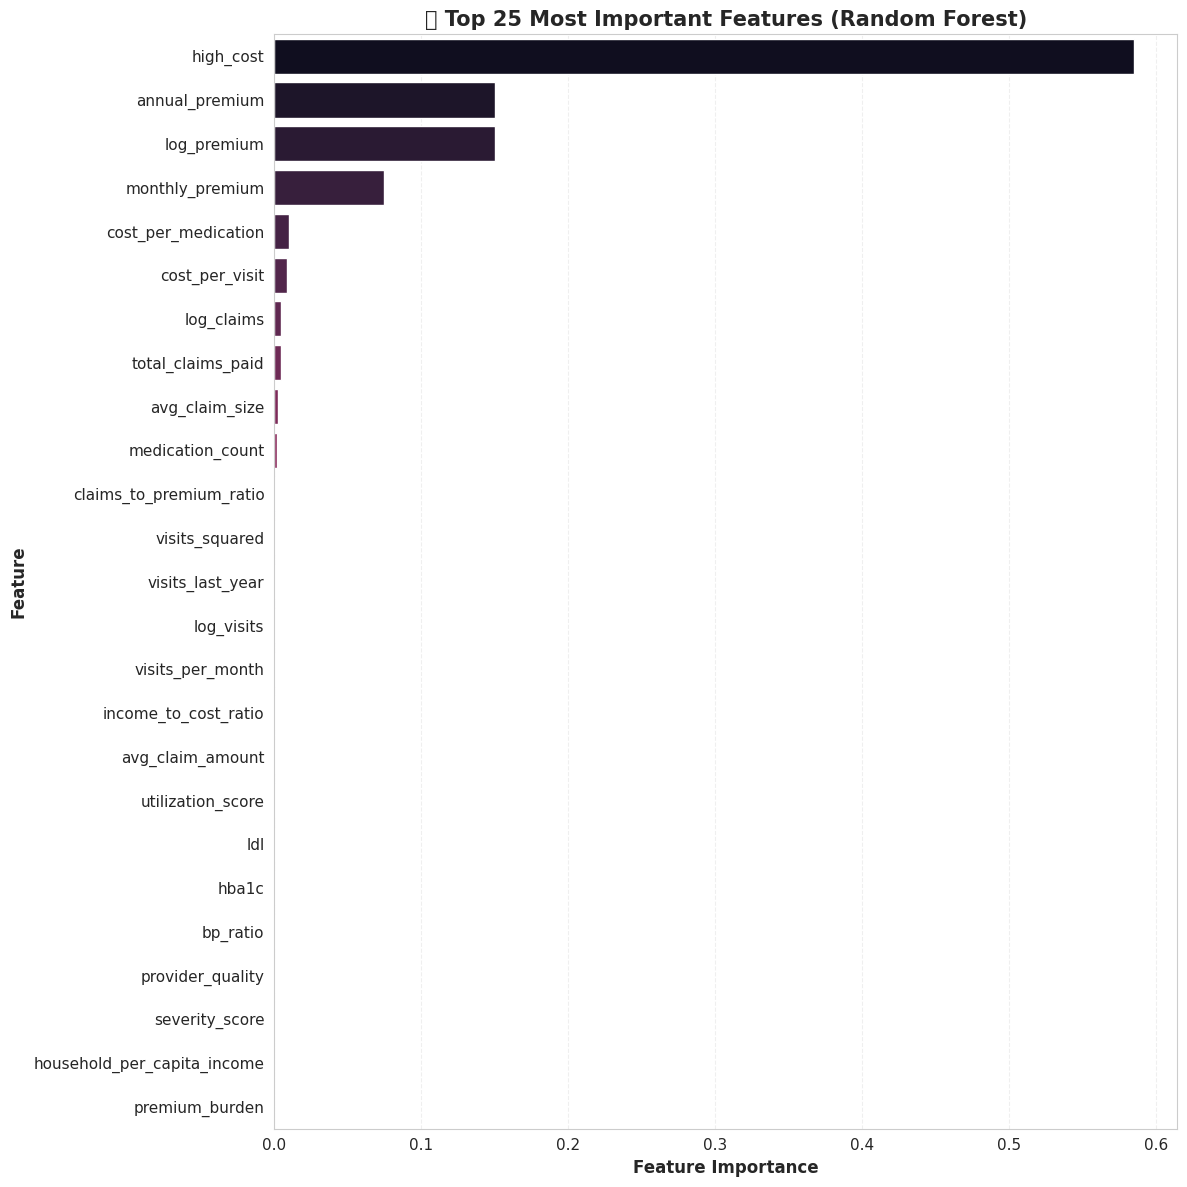

💡 TOP 20 MOST IMPORTANT FEATURES
high_cost......................................... 0.5848
annual_premium.................................... 0.1504
log_premium....................................... 0.1502
monthly_premium................................... 0.0746
cost_per_medication............................... 0.0098
cost_per_visit.................................... 0.0086
log_claims........................................ 0.0048
total_claims_paid................................. 0.0043
avg_claim_size.................................... 0.0022
medication_count.................................. 0.0015
claims_to_premium_ratio........................... 0.0008
visits_squared.................................... 0.0007
visits_last_year.................................. 0.0006
log_visits........................................ 0.0006
visits_per_month.................................. 0.0006
income_to_cost_ratio.............................. 0.0004
avg_claim_amount.......................

In [38]:
# Quick feature importance check using Random Forest
from sklearn.ensemble import RandomForestRegressor

# Prepare data (select only numeric features)
drop_cols = ['annual_medical_cost', 'log_medical_cost', 'person_id', 'bmi_category',
             'cost_range', 'age_group', 'hosp_category', 'med_category', 'deduct_category',
             'sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status',
             'plan_type', 'network_tier']

X_temp = df_fe.drop(drop_cols, axis=1, errors='ignore')

# Keep only numeric features
X_temp = X_temp.select_dtypes(include=[np.number])

# Fill any NaN values
X_temp = X_temp.fillna(X_temp.mean())

y_temp = df_fe['annual_medical_cost']

# Quick RF for feature importance
print("Training Random Forest for feature importance analysis...")
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_temp.fit(X_temp, y_temp)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': X_temp.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False).head(25)

# Visualize
fig, ax = plt.subplots(figsize=(12, 12))
sns.barplot(data=feature_importance, y='feature', x='importance', palette='rocket', ax=ax)
ax.set_title('🎯 Top 25 Most Important Features (Random Forest)', fontsize=15, fontweight='bold')
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

print("="*70)
print("💡 TOP 20 MOST IMPORTANT FEATURES")
print("="*70)
for idx, row in feature_importance.head(20).iterrows():
    print(f"{row['feature']:.<50} {row['importance']:.4f}")
print("="*70)

MODELING

In [39]:
# Prepare final dataset for modeling
print("="*70)
print("📦 PREPARING DATA FOR MODELING")
print("="*70)

# Select features (drop target and categorical columns)
drop_cols = ['annual_medical_cost', 'log_medical_cost', 'person_id', 'bmi_category',
             'cost_range', 'age_group', 'hosp_category', 'med_category', 'deduct_category',
             'sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status',
             'plan_type', 'network_tier', 'income_to_cost_ratio', 'cost_per_visit',
             'cost_per_medication', 'avg_claim_size']  # Remove target leakage features

X = df_fe.drop(drop_cols, axis=1, errors='ignore')

# Keep only numeric features
X = X.select_dtypes(include=[np.number])

# Fill any NaN values
X = X.fillna(X.mean())

# Target variable
y = df_fe['annual_medical_cost']

print(f"✓ Features shape: {X.shape}")
print(f"✓ Target shape: {y.shape}")
print(f"✓ Number of features: {X.shape[1]}")

# Train-Test Split (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✓ Training set: {X_train.shape[0]:,} samples")
print(f"✓ Test set: {X_test.shape[0]:,} samples")
print(f"✓ Train mean cost: ${y_train.mean():,.2f}")
print(f"✓ Test mean cost: ${y_test.mean():,.2f}")

# Feature Scaling (Important for distance-based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features scaled using StandardScaler")
print("="*70)

# Display first few features being used
print(f"\n📋 First 20 Features being used:\n")
for i, col in enumerate(X.columns[:20], 1):
    print(f"{i:2}. {col}")
print(f"... and {len(X.columns) - 20} more features")

📦 PREPARING DATA FOR MODELING
✓ Features shape: (100000, 105)
✓ Target shape: (100000,)
✓ Number of features: 105

✓ Training set: 80,000 samples
✓ Test set: 20,000 samples
✓ Train mean cost: $3,004.87
✓ Test mean cost: $3,027.79

✓ Features scaled using StandardScaler

📋 First 20 Features being used:

 1. age
 2. income
 3. household_size
 4. dependents
 5. bmi
 6. visits_last_year
 7. hospitalizations_last_3yrs
 8. days_hospitalized_last_3yrs
 9. medication_count
10. systolic_bp
11. diastolic_bp
12. ldl
13. hba1c
14. deductible
15. copay
16. policy_term_years
17. policy_changes_last_2yrs
18. provider_quality
19. risk_score
20. annual_premium
... and 85 more features


In [40]:
for col in X.columns:
    print(col)

age
income
household_size
dependents
bmi
visits_last_year
hospitalizations_last_3yrs
days_hospitalized_last_3yrs
medication_count
systolic_bp
diastolic_bp
ldl
hba1c
deductible
copay
policy_term_years
policy_changes_last_2yrs
provider_quality
risk_score
annual_premium
monthly_premium
claims_count
avg_claim_amount
total_claims_paid
chronic_count
hypertension
diabetes
asthma
copd
cardiovascular_disease
cancer_history
kidney_disease
liver_disease
arthritis
mental_health
proc_imaging_count
proc_surgery_count
proc_physio_count
proc_consult_count
proc_lab_count
is_high_risk
had_major_procedure
high_cost
disease_count
risk_x_disease
risk_x_hospital
severity_score
visits_per_month
hosp_intensity
days_per_hospitalization
total_procedures
utilization_score
cardiovascular_risk
complex_patient
high_risk_patient
critical_conditions
age_chronic_interaction
age_risk_score
elderly_chronic
young_high_risk
premium_burden
deductible_to_income
out_of_pocket_risk
coverage_adequacy
is_obese
is_overweight
smo

In [41]:
# Initialize multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=10.0, random_state=42),
    'Lasso': Lasso(alpha=10.0, random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=10.0, random_state=42, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42, max_depth=7),
    'XGBoost': XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1, max_depth=7, learning_rate=0.1),
    'LightGBM': LGBMRegressor(n_estimators=200, random_state=42, verbose=-1, n_jobs=-1, max_depth=7),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42, learning_rate=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'KNN': KNeighborsRegressor(n_neighbors=7)
}

# Store results
results = []
trained_models = {}

print("="*70)
print("🚀 TRAINING MODELS - PLEASE WAIT...")
print("="*70)

for name, model in models.items():
    print(f"\n⚙️  Training {name}...")

    # Use scaled data for distance-based and linear models
    if name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    # Train model
    model.fit(X_tr, y_train)

    # Predictions
    y_pred = model.predict(X_te)

    # Clip negative predictions
    y_pred = np.maximum(y_pred, 0)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    # Store results
    results.append({
        'Model': name,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    })

    # Store trained model
    trained_models[name] = model

    print(f"   ✓ R²: {r2:.4f} | RMSE: ${rmse:,.2f} | MAE: ${mae:,.2f} | MAPE: {mape:.2f}%")

# Create results DataFrame
results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)

print("\n" + "="*70)
print("📊 MODEL COMPARISON RESULTS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

🚀 TRAINING MODELS - PLEASE WAIT...

⚙️  Training Linear Regression...
   ✓ R²: 0.9489 | RMSE: $708.85 | MAE: $416.17 | MAPE: 17.97%

⚙️  Training Ridge...
   ✓ R²: 0.9489 | RMSE: $708.82 | MAE: $416.06 | MAPE: 17.95%

⚙️  Training Lasso...
   ✓ R²: 0.9488 | RMSE: $709.94 | MAE: $410.38 | MAPE: 16.87%

⚙️  Training ElasticNet...
   ✓ R²: 0.6864 | RMSE: $1,756.77 | MAE: $1,045.28 | MAPE: 62.11%

⚙️  Training Random Forest...
   ✓ R²: 0.9550 | RMSE: $665.14 | MAE: $360.60 | MAPE: 12.79%

⚙️  Training Gradient Boosting...
   ✓ R²: 0.9542 | RMSE: $671.16 | MAE: $363.06 | MAPE: 12.91%

⚙️  Training XGBoost...
   ✓ R²: 0.9367 | RMSE: $789.27 | MAE: $371.38 | MAPE: 12.93%

⚙️  Training LightGBM...
   ✓ R²: 0.9382 | RMSE: $779.98 | MAE: $373.55 | MAPE: 13.16%

⚙️  Training AdaBoost...
   ✓ R²: 0.9179 | RMSE: $898.80 | MAE: $642.37 | MAPE: 46.25%

⚙️  Training Decision Tree...
   ✓ R²: 0.9402 | RMSE: $767.17 | MAE: $383.55 | MAPE: 13.49%

⚙️  Training KNN...
   ✓ R²: 0.7938 | RMSE: $1,424.47 | M

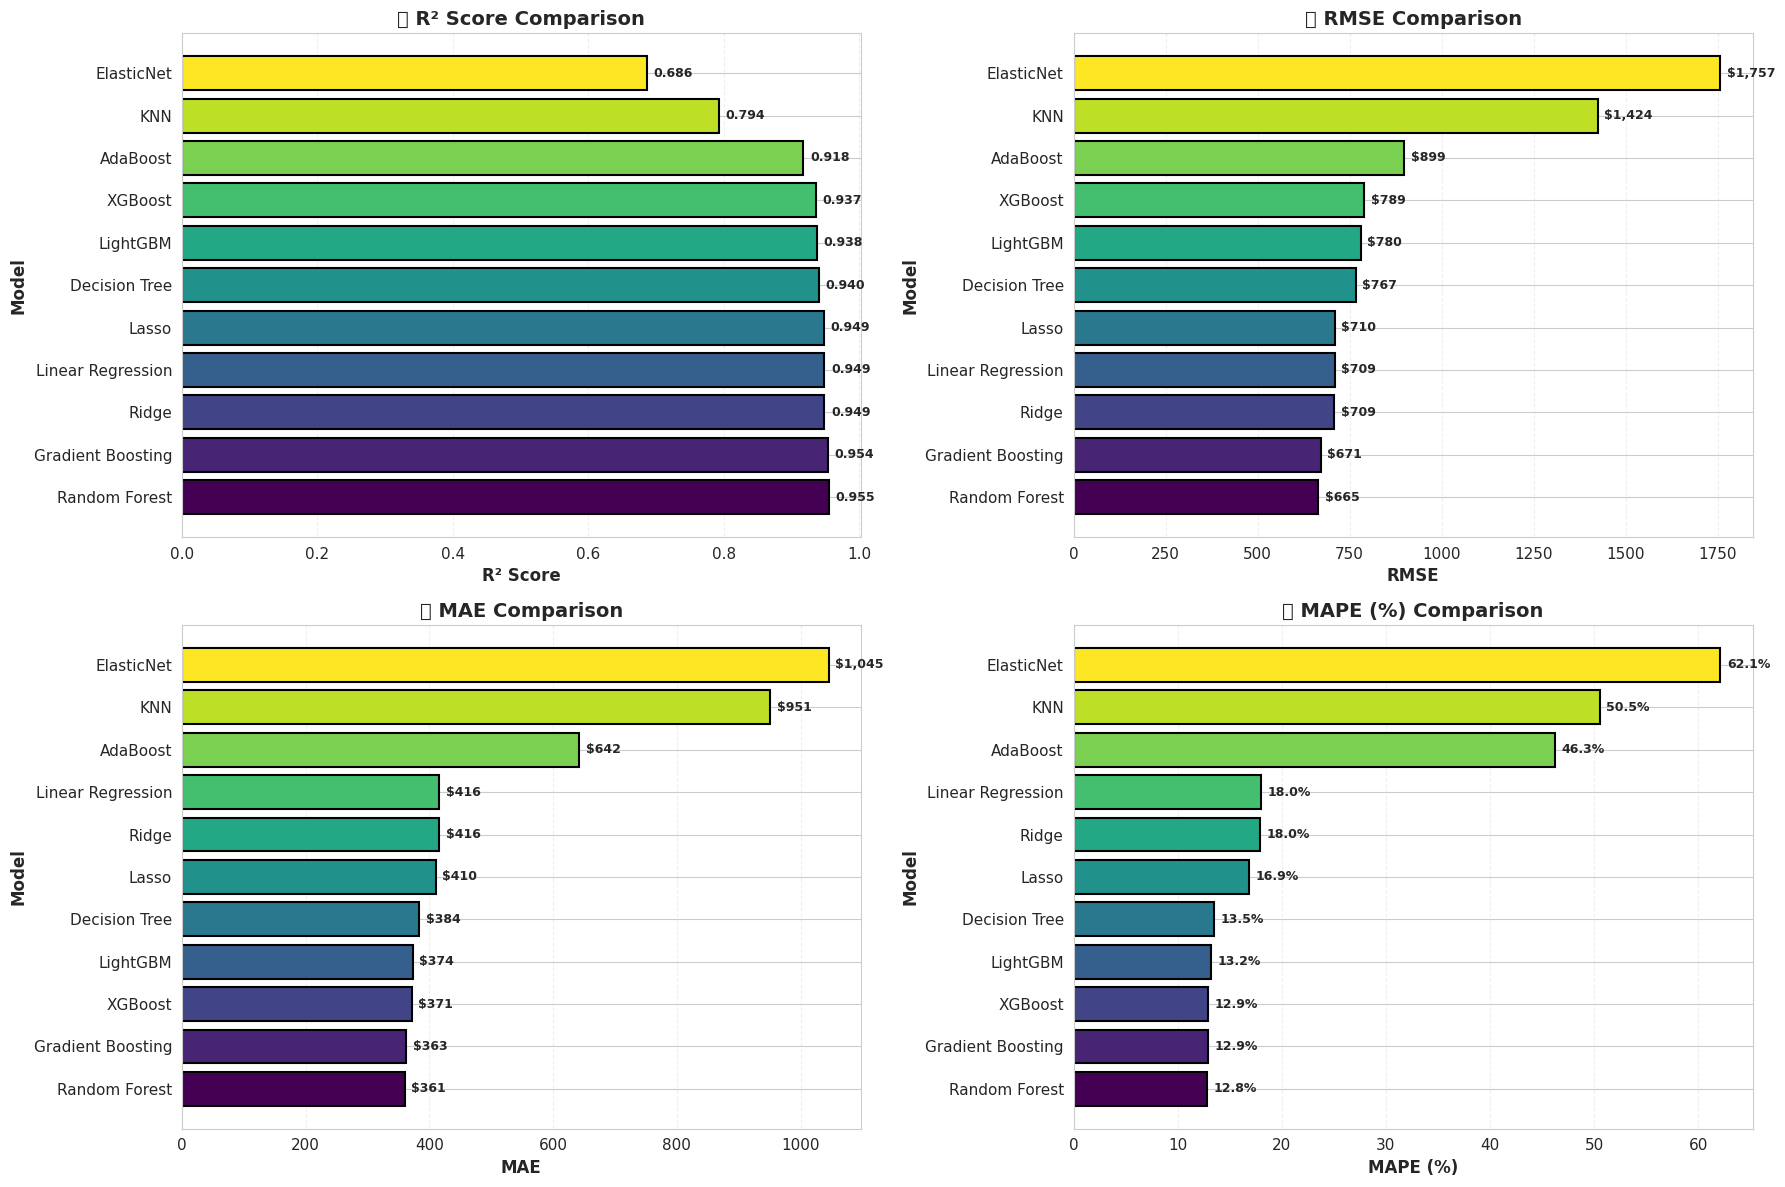

🏆 FINAL MODEL RANKINGS (by R² Score)
 1. Random Forest................. R²: 0.9550 | RMSE: $665
 2. Gradient Boosting............. R²: 0.9542 | RMSE: $671
 3. Ridge......................... R²: 0.9489 | RMSE: $709
 4. Linear Regression............. R²: 0.9489 | RMSE: $709
 5. Lasso......................... R²: 0.9488 | RMSE: $710
 6. Decision Tree................. R²: 0.9402 | RMSE: $767
 7. LightGBM...................... R²: 0.9382 | RMSE: $780
 8. XGBoost....................... R²: 0.9367 | RMSE: $789
 9. AdaBoost...................... R²: 0.9179 | RMSE: $899
10. KNN........................... R²: 0.7938 | RMSE: $1,424
11. ElasticNet.................... R²: 0.6864 | RMSE: $1,757


In [42]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Metrics to plot
metrics = ['R² Score', 'RMSE', 'MAE', 'MAPE (%)']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    # Sort by metric (ascending for error metrics, descending for R²)
    ascending = False if metric == 'R² Score' else True
    data = results_df.sort_values(metric, ascending=ascending)

    # Create horizontal bar plot
    bars = ax.barh(data['Model'], data[metric],
                  color=plt.cm.viridis(np.linspace(0, 1, len(data))),
                  edgecolor='black', linewidth=1.5)

    # Add value labels
    for bar in bars:
        width = bar.get_width()
        label_x_pos = width + (max(data[metric]) * 0.01)
        if metric == 'R² Score':
            label_text = f'{width:.3f}'
        elif metric == 'MAPE (%)':
            label_text = f'{width:.1f}%'
        else:
            label_text = f'${width:,.0f}'

        ax.text(label_x_pos, bar.get_y() + bar.get_height()/2,
               label_text, ha='left', va='center', fontweight='bold', fontsize=9)

    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_title(f'📊 {metric} Comparison', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

# Overall ranking
print("="*70)
print("🏆 FINAL MODEL RANKINGS (by R² Score)")
print("="*70)
for idx, (i, row) in enumerate(results_df.iterrows(), 1):
    print(f"{idx:2}. {row['Model']:.<30} R²: {row['R² Score']:.4f} | RMSE: ${row['RMSE']:,.0f}")
print("="*70)

🏆 BEST MODEL: Random Forest

📊 PERFORMANCE METRICS:
   • R² Score: 0.9550 (95.50% variance explained)
   • RMSE: $665.14
   • MAE: $360.60
   • MAPE: 12.79%


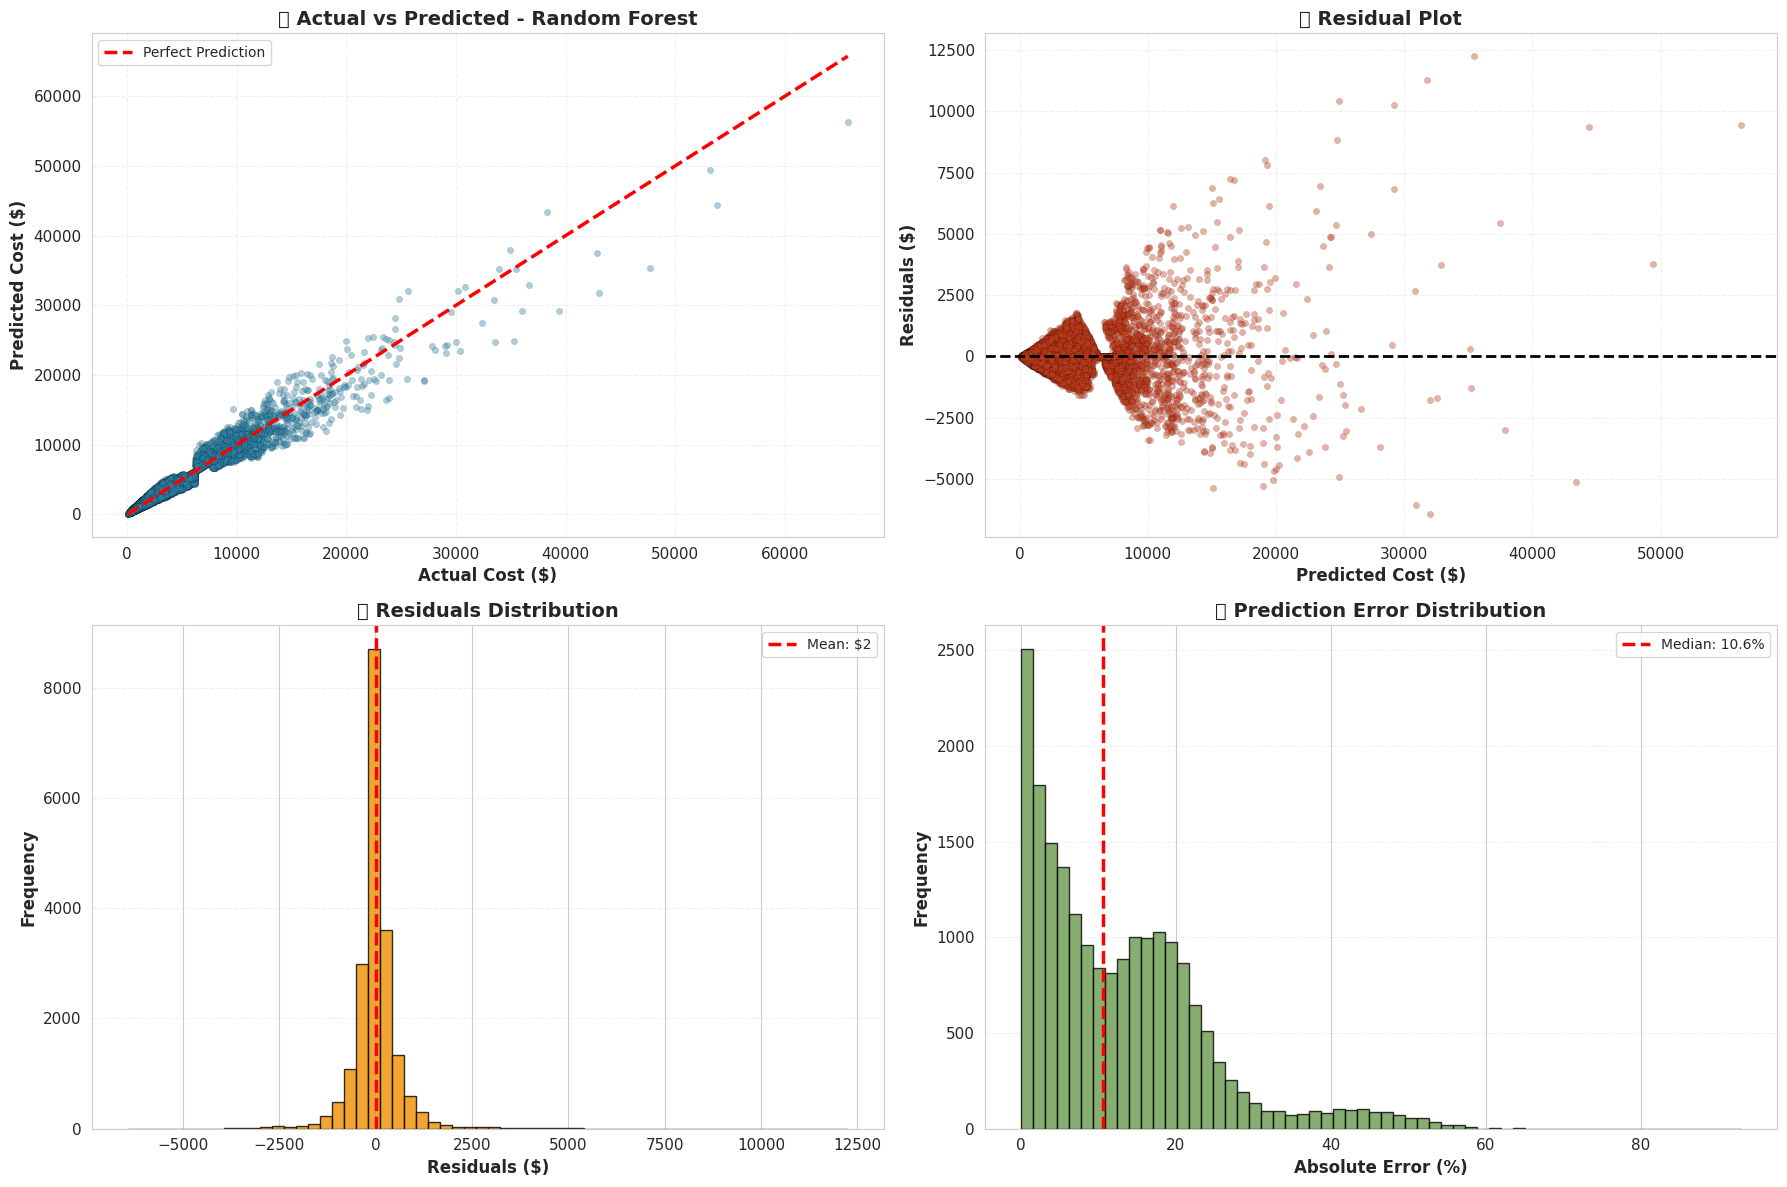


💡 PREDICTION ERROR ANALYSIS
✓ Mean residual: $2.21
✓ Std of residuals: $665.15
✓ Median absolute error: 10.65%
✓ Predictions within 10% error: 9,659 (48.3%)
✓ Predictions within 20% error: 15,725 (78.6%)
✓ Predictions within 30% error: 18,658 (93.3%)


In [43]:
# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("="*70)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*70)

# Get predictions
if best_model_name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN']:
    X_te = X_test_scaled
else:
    X_te = X_test

y_pred = best_model.predict(X_te)
y_pred = np.maximum(y_pred, 0)  # Clip negative predictions

# Detailed metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"\n📊 PERFORMANCE METRICS:")
print(f"   • R² Score: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"   • RMSE: ${rmse:,.2f}")
print(f"   • MAE: ${mae:,.2f}")
print(f"   • MAPE: {mape:.2f}%")

# Prediction analysis
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top-left: Actual vs Predicted scatter
axes[0,0].scatter(y_test, y_pred, alpha=0.4, s=20, c='#2E86AB', edgecolors='black', linewidth=0.2)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
              'r--', linewidth=2.5, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual Cost ($)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Predicted Cost ($)', fontsize=12, fontweight='bold')
axes[0,0].set_title(f'🎯 Actual vs Predicted - {best_model_name}', fontsize=14, fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].grid(alpha=0.3, linestyle='--')

# Top-right: Residuals plot
residuals = y_test - y_pred
axes[0,1].scatter(y_pred, residuals, alpha=0.4, s=20, c='#C73E1D', edgecolors='black', linewidth=0.2)
axes[0,1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0,1].set_xlabel('Predicted Cost ($)', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[0,1].set_title('📉 Residual Plot', fontsize=14, fontweight='bold')
axes[0,1].grid(alpha=0.3, linestyle='--')

# Bottom-left: Residuals distribution
axes[1,0].hist(residuals, bins=60, color='#F18F01', edgecolor='black', alpha=0.8)
axes[1,0].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2.5,
                 label=f'Mean: ${residuals.mean():,.0f}')
axes[1,0].set_xlabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1,0].set_title('📊 Residuals Distribution', fontsize=14, fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(alpha=0.3, axis='y', linestyle='--')

# Bottom-right: Error percentage distribution
error_pct = np.abs((y_test - y_pred) / y_test) * 100
axes[1,1].hist(error_pct, bins=60, color='#6A994E', edgecolor='black', alpha=0.8)
axes[1,1].axvline(error_pct.median(), color='red', linestyle='--', linewidth=2.5,
                 label=f'Median: {error_pct.median():.1f}%')
axes[1,1].set_xlabel('Absolute Error (%)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1,1].set_title('📈 Prediction Error Distribution', fontsize=14, fontweight='bold')
axes[1,1].legend(fontsize=10)
axes[1,1].grid(alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

# Error analysis
print("\n" + "="*70)
print("💡 PREDICTION ERROR ANALYSIS")
print("="*70)
print(f"✓ Mean residual: ${residuals.mean():,.2f}")
print(f"✓ Std of residuals: ${residuals.std():,.2f}")
print(f"✓ Median absolute error: {error_pct.median():.2f}%")
print(f"✓ Predictions within 10% error: {(error_pct < 10).sum():,} ({(error_pct < 10).mean()*100:.1f}%)")
print(f"✓ Predictions within 20% error: {(error_pct < 20).sum():,} ({(error_pct < 20).mean()*100:.1f}%)")
print(f"✓ Predictions within 30% error: {(error_pct < 30).sum():,} ({(error_pct < 30).mean()*100:.1f}%)")
print("="*70)

In [44]:
import joblib

# ambil model terbaik
best_model = trained_models['Random Forest']

# save model
joblib.dump(best_model, 'best_rf_model.pkl')

# save scaler
joblib.dump(scaler, 'scaler.pkl')

# save feature columns
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("✅ Random Forest model saved!")

✅ Random Forest model saved!


In [48]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# ======================
# LOAD FILES
# ======================
model = joblib.load("best_rf_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# ======================
# TITLE
# ======================
st.title("🏥 Medical Cost Prediction")

st.write("Input patient information below")

# ======================
# USER INPUT
# ======================
age = st.number_input("Age", 1, 100, 30)

income = st.number_input("Income", 0.0, 1000000.0, 50000.0)

bmi = st.number_input("BMI", 10.0, 60.0, 25.0)

chronic_count = st.number_input("Chronic Count", 0, 10, 0)

visits_last_year = st.number_input("Visits Last Year", 0, 50, 2)

medication_count = st.number_input("Medication Count", 0, 20, 1)

risk_score = st.slider("Risk Score", 0.0, 1.0, 0.3)

annual_premium = st.number_input("Annual Premium", 0.0, 50000.0, 2000.0)

deductible = st.number_input("Deductible", 0.0, 10000.0, 1000.0)

copay = st.number_input("Copay", 0.0, 500.0, 20.0)

# ======================
# FEATURE ENGINEERING
# ======================
input_dict = {
    "age": age,
    "income": income,
    "bmi": bmi,
    "chronic_count": chronic_count,
    "visits_last_year": visits_last_year,
    "medication_count": medication_count,
    "risk_score": risk_score,
    "annual_premium": annual_premium,
    "deductible": deductible,
    "copay": copay
}

input_df = pd.DataFrame([input_dict])

# engineered features
input_df["visits_per_month"] = input_df["visits_last_year"] / 12

input_df["utilization_score"] = (
    input_df["visits_last_year"] +
    (input_df["medication_count"] * 2)
)

input_df["age_chronic_interaction"] = (
    input_df["age"] *
    input_df["chronic_count"]
)

input_df["premium_burden"] = (
    input_df["annual_premium"] /
    (input_df["income"] + 1)
)

input_df["deductible_to_income"] = (
    input_df["deductible"] /
    (input_df["income"] + 1)
)

input_df["out_of_pocket_risk"] = (
    input_df["deductible"] +
    input_df["copay"]
)

input_df["is_obese"] = (
    input_df["bmi"] >= 30
).astype(int)

input_df["is_overweight"] = (
    input_df["bmi"] >= 25
).astype(int)

input_df["age_squared"] = input_df["age"] ** 2

input_df["bmi_squared"] = input_df["bmi"] ** 2

input_df["chronic_squared"] = (
    input_df["chronic_count"] ** 2
)

input_df["visits_squared"] = (
    input_df["visits_last_year"] ** 2
)

input_df["log_income"] = np.log1p(input_df["income"])

input_df["log_premium"] = np.log1p(input_df["annual_premium"])

input_df["log_visits"] = np.log1p(input_df["visits_last_year"])

# ======================
# ALIGN COLUMNS
# ======================
for col in feature_columns:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[feature_columns]

# ======================
# SCALING
# ======================
input_scaled = scaler.transform(input_df)

# ======================
# PREDICTION
# ======================
if st.button("Predict Medical Cost"):

    prediction = model.predict(input_scaled)[0]

    st.success(
        f"💰 Predicted Annual Medical Cost: ${prediction:,.2f}"
    )

2026-05-12 16:10:35.957 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.958 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.962 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.963 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.964 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.967 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 16:10:35.969 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [51]:
!pip install streamlit pyngrok

In [53]:
!ngrok config add-authtoken #TOKEN

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [57]:
!streamlit run app.py &>/dev/null &

In [58]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://radiochemical-abrielle-periclinal.ngrok-free.dev" -> "http://localhost:8501"
